# Load and if you want, remove certain datasets


In [3]:
import os
import numpy as np
import pandas as pd
from PIL import Image

# Parameters
# Parameters
main_folders = [f"S{i}" for i in range(1, 51)]  # Main folders S1 to S50
sub_folders = ["patches", "patches_Brightness", "patches_flipped", "patches_Noise", "patches_rotated"]

# Remove 'patches_Brightness' from the sub_folders list
sub_folders.remove("patches_Brightness")


base_path = "G:/0000_New_Samples"
img_size = (150, 150)  # Assuming each image is 150x150 pixels
grid_size = 24  # Grid cell size (assuming square grid cells)
n_cells = (img_size[0] // grid_size) * (img_size[1] // grid_size)  # Number of cells
n_phases = 6  # Number of phases including the background

# Initialize lists to hold images and labels
images = []
labels = []

# Function to preprocess and load data
def load_and_preprocess_data():
    for main_folder in main_folders:
        for sub_folder in sub_folders:
            current_path = os.path.join(base_path, main_folder, sub_folder)
            for file in os.listdir(current_path):
                if file.endswith(".png"):
                    # Load the image
                    img_path = os.path.join(current_path, file)
                    with Image.open(img_path) as img:
                        img_array = np.array(img) / 255.0  # Normalize the image
                        img_array = img_array.reshape((*img_size, 1))  # Add channel dimension
                        images.append(img_array)

                    # Load the corresponding CSV
                    csv_file = file.replace("P_sub_", "A_sub_").replace(".png", ".csv")
                    csv_path = os.path.join(current_path, csv_file)
                    if os.path.exists(csv_path):
                        df = pd.read_csv(csv_path)

                        # Create grid to match image based on grid size
                        label_grid = np.zeros((img_size[0] // grid_size, img_size[1] // grid_size, n_phases))
                        for index, row in df.iterrows():
                            # Adjust x and y to be in terms of grid cells, not pixel coordinates
                            cell_x = int((row['x'] % img_size[1]) // grid_size)
                            cell_y = int((row['y'] % img_size[0]) // grid_size)

                            if 0 <= cell_x < label_grid.shape[1] and 0 <= cell_y < label_grid.shape[0]:
                                label_grid[cell_y, cell_x] = row[['B', 'C1', 'C2', 'C3', 'C4', 'C5']].values
                            else:
                                print(f"Skipping out-of-bounds index at x: {row['x']}, y: {row['y']}")

                        labels.append(label_grid.reshape(-1, n_phases))  # Flatten grid to match with images
                    else:
                        print(f"Warning: CSV file {csv_file} not found for image {file}.")


# Run the preprocessing function
load_and_preprocess_data()

# Convert lists to NumPy arrays
images = np.array(images)
labels = np.array(labels)

# Check shapes of arrays
print(f"images shape: {images.shape}")
print(f"labels shape: {labels.shape}")

# Now 'images' and 'labels' are NumPy arrays ready for use in training a CNN.
# The shape of 'images' will be (number of images, 150, 150, 1)
# The shape of 'labels' will be (number of images, number of grid cells, 6)


In [2]:
# Reshape labels to match U-Net output
labels = np.reshape(labels, (-1, 6, 6, n_phases))

print(f"Reshaped labels shape: {labels.shape}")


Reshaped labels shape: (16632, 6, 6, 6)


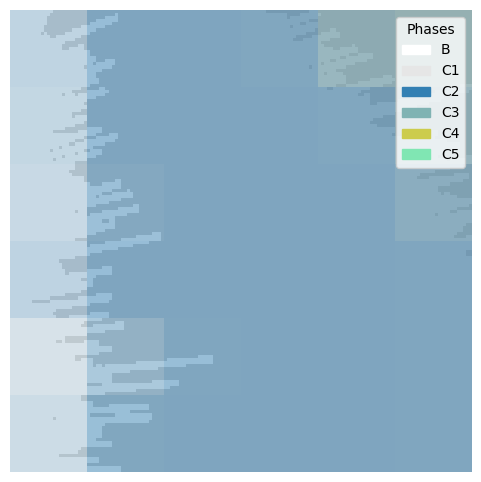

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

# For demonstration, assume these variables have been created by our preprocessing:
# images shape: (num_images, 150, 150, 1)
# labels shape: (num_images, 6, 6, 6)
example_index =10 # Choose an example index
image_example = images[example_index].squeeze()  # (150,150)
label_grid = labels[example_index]  # shape (6,6,6)

# Define the color map for each phase (RGB, [0,1])
phase_colors = {
    'B': np.array([1.0, 1.0, 1.0]),
    'C1': np.array([0.9, 0.9, 0.9]),
    'C2': np.array([0.2, 0.5, 0.7]),
    'C3': np.array([0.5, 0.7, 0.7]),
    'C4': np.array([0.8, 0.8, 0.3]),
    'C5': np.array([0.5, 0.9, 0.7])
}
phase_order = ['B', 'C1', 'C2', 'C3', 'C4', 'C5']

# Image and grid dimensions
img_height, img_width = 150, 150
grid_rows, grid_cols = 6, 6
cell_height, cell_width = img_height // grid_rows, img_width // grid_cols

# Initialize overlay (RGBA channels, values in [0,1])
overlay = np.zeros((img_height, img_width, 4), dtype=np.float32)

# Fill the overlay with composite color for each cell
for i in range(grid_rows):
    for j in range(grid_cols):
        fractions = label_grid[i, j]  # For phases in order [B, C1, C2, C3, C4, C5]
        weighted_color = np.zeros(3)
        total_alpha = 0.0
        for k, phase in enumerate(phase_order):
            weighted_color += fractions[k] * phase_colors[phase]
            total_alpha += fractions[k]
        rgba = np.append(weighted_color, total_alpha)
        y0 = i * cell_height
        y1 = y0 + cell_height
        x0 = j * cell_width
        x1 = x0 + cell_width
        overlay[y0:y1, x0:x1, :] = rgba

# Adjust overall opacity by modifying the alpha channel
overall_opacity = 0.5  # 50% opacity; change this between 0 and 1 as desired.
overlay[..., 3] *= overall_opacity

overlay = np.clip(overlay, 0, 1)

# Convert overlay to PIL image
overlay_image = Image.fromarray((overlay * 255).astype(np.uint8), mode='RGBA')
original_image_pil = Image.fromarray((image_example * 255).astype(np.uint8)).convert('RGBA')

# Composite the overlay onto the original image
blended_image = Image.alpha_composite(original_image_pil, overlay_image)

# Display the final blended image
plt.figure(figsize=(6, 6))
plt.imshow(blended_image)
plt.axis('off')

# Create a legend for the phases
patches = [mpatches.Patch(color=phase_colors[key], label=key) for key in phase_order]
plt.legend(handles=patches, loc='upper right', title="Phases")
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Mahdieh\AppData\Local\Temp\ipykernel_30124\1274546899.py:45: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(all_pixels, shade=True, color='dodgerblue')
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


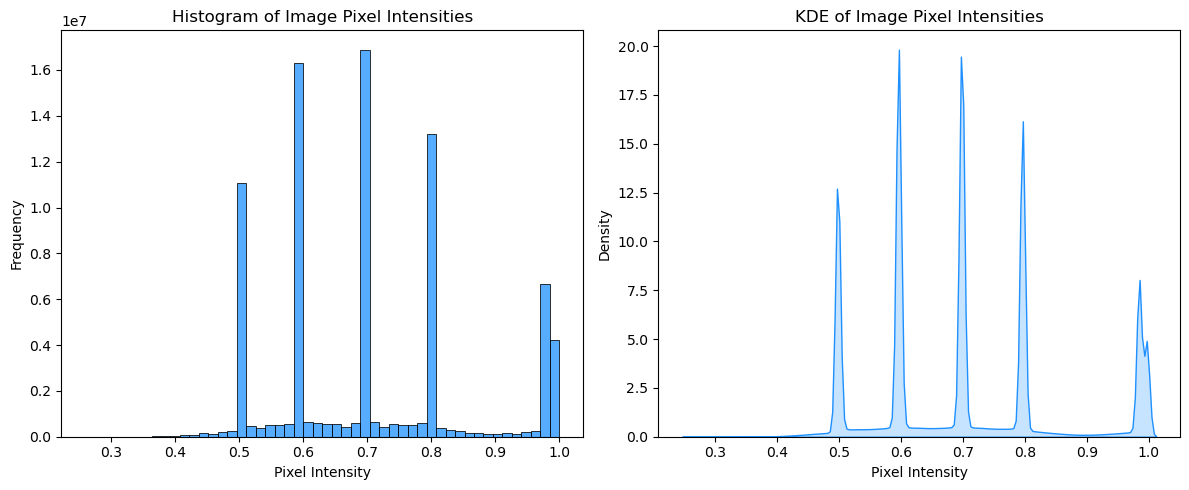

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Optionally, if you have UMAP installed:
try:
    import umap
    have_umap = True
except ImportError:
    have_umap = False

# ------------------------------------------------------------------------------
# ASSUMPTIONS:
#   - 'images' is a NumPy array with shape (num_images, 150, 150, 1)
#   - 'labels' is a NumPy array with shape (num_images, 6, 6, 6)
# ------------------------------------------------------------------------------
# For demonstration purposes, if you want to test with dummy data, uncomment:
# np.random.seed(42)
# num_images = 100
# images = np.random.rand(num_images, 150, 150, 1)
# labels = np.random.rand(num_images, 6, 6, 6)

# If your arrays are already loaded from your preprocessing code, you can skip the above.

num_images = images.shape[0]

# ------------------------------------------------------------------------------
# 1. VISUAL INSPECTION: Histograms & Density Plots for Image Pixel Intensities
# ------------------------------------------------------------------------------
# Flatten all pixel values across all images (images are assumed to be normalized [0,1])
all_pixels = images.flatten()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(all_pixels, bins=50, color='dodgerblue', kde=False)
plt.title("Histogram of Image Pixel Intensities")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.kdeplot(all_pixels, shade=True, color='dodgerblue')
plt.title("KDE of Image Pixel Intensities")
plt.xlabel("Pixel Intensity")
plt.ylabel("Density")

plt.tight_layout()
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

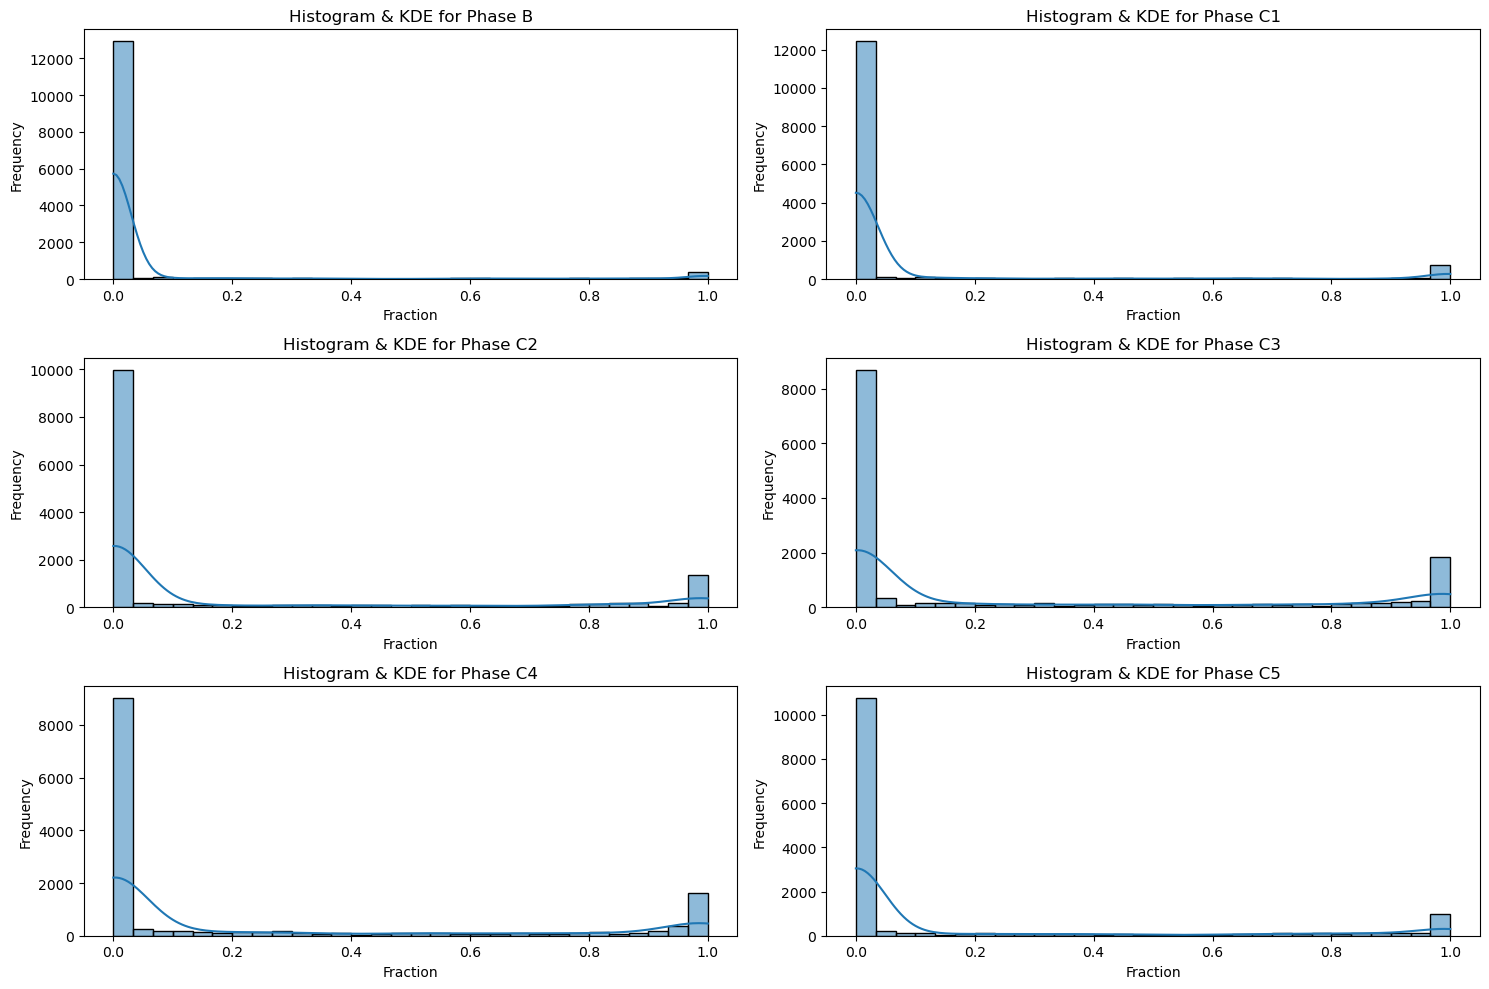

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
# ------------------------------------------------------------------------------
# 2. VISUAL INSPECTION: Labels' Distributions for Each Phase
# ------------------------------------------------------------------------------
# Each label for one image is of shape (6,6,6), where the last dimension represents phases:
phase_names = ['B', 'C1', 'C2', 'C3', 'C4', 'C5']
label_values = {}  # To hold flattened values for each phase
for i, phase in enumerate(phase_names):
    # Extract the ith phase value from every cell of every image and flatten
    label_values[phase] = labels[:, :, :, i].flatten()

# Create histograms and KDE plots for each phase
plt.figure(figsize=(15, 10))
for idx, phase in enumerate(phase_names):
    plt.subplot(3, 2, idx+1)
    sns.histplot(label_values[phase], bins=30, kde=True)
    plt.title(f"Histogram & KDE for Phase {phase}")
    plt.xlabel("Fraction")
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


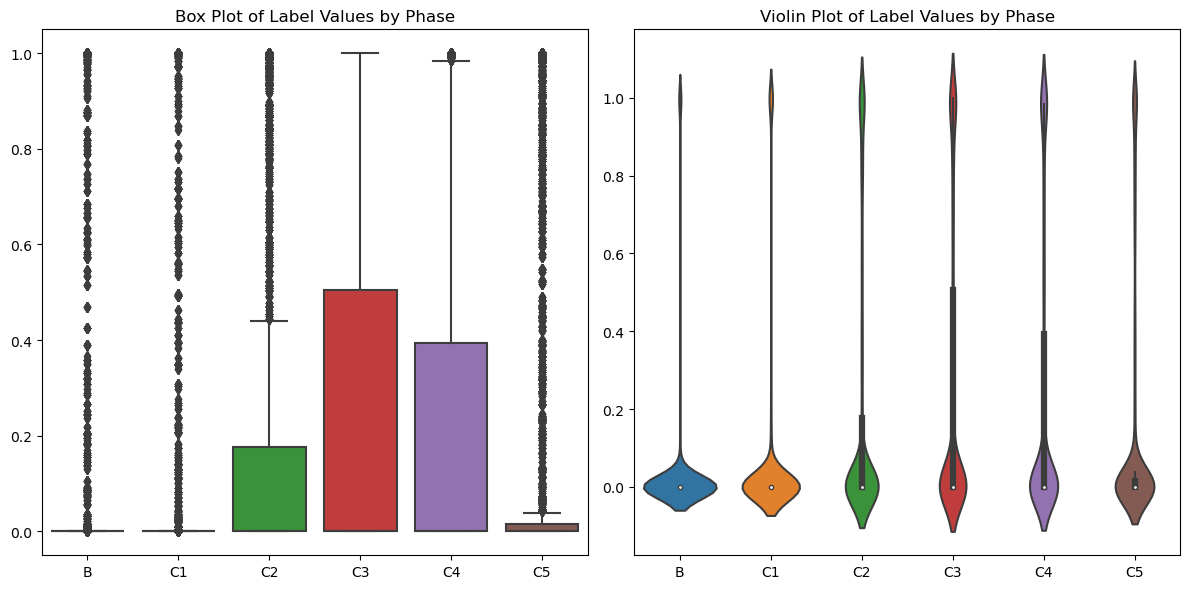

In [5]:

# Create DataFrame for box and violin plots
df_labels = pd.DataFrame({phase: label_values[phase] for phase in phase_names})

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=df_labels)
plt.title("Box Plot of Label Values by Phase")
plt.subplot(1, 2, 2)
sns.violinplot(data=df_labels)
plt.title("Violin Plot of Label Values by Phase")
plt.tight_layout()
plt.show()


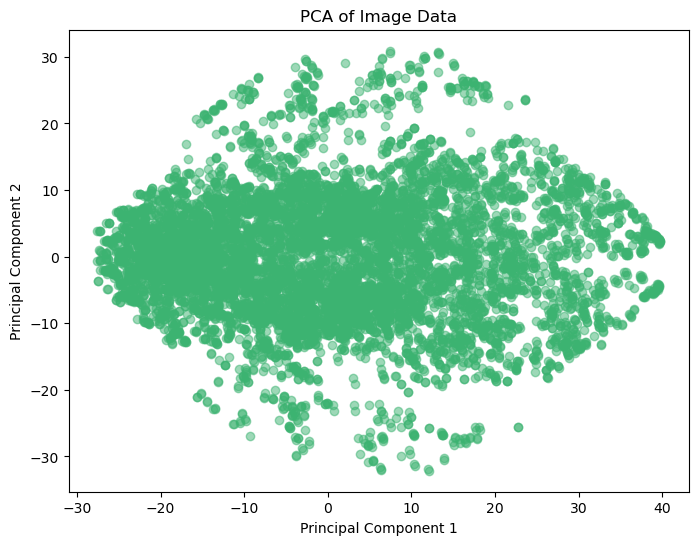

In [5]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

num_images = images.shape[0]

# ------------------------------------------------------------------------------
# 3. DIMENSIONALITY REDUCTION of Image Data
# ------------------------------------------------------------------------------
# Flatten each image from (150,150,1) to a 1D vector of length 150*150.
images_flat = images.reshape(num_images, -1)

# --- 3A. PCA ---
pca = PCA(n_components=2)
pca_result = pca.fit_transform(images_flat)
plt.figure(figsize=(8,6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5, color='mediumseagreen')
plt.title("PCA of Image Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()



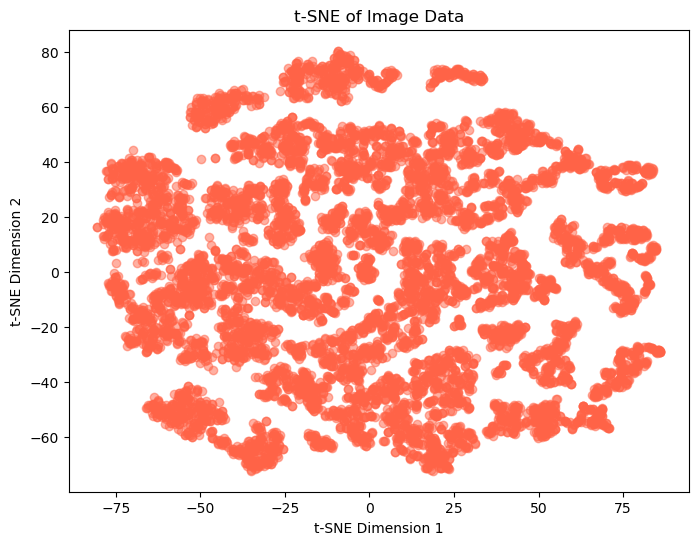

In [6]:
# --- 3B. t-SNE ---
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(images_flat)
plt.figure(figsize=(8,6))
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], alpha=0.5, color='mediumseagreen')
plt.title("t-SNE of Image Data")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()



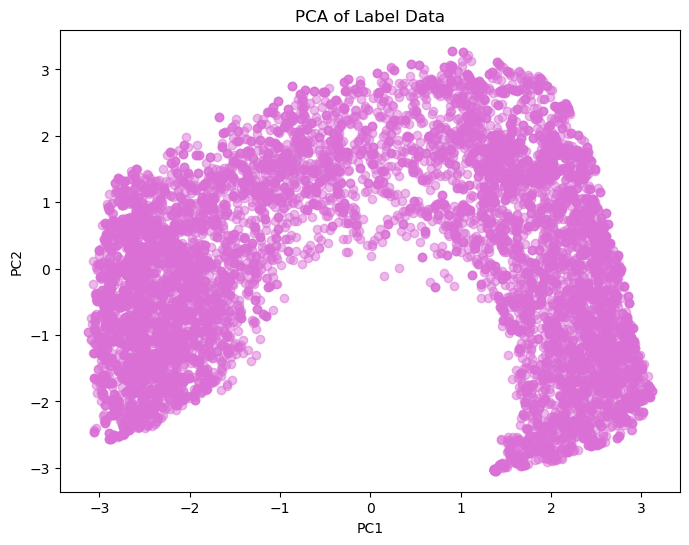

In [7]:
# ------------------------------------------------------------------------------
# (Optional) perform dimensionality reduction on the label data,
# for example by flattening the label grid for each image.
# For instance, reshape labels: (num_images, 6,6,6) -> (num_images, 6*6*6)
labels_flat = labels.reshape(num_images, -1)
pca_labels = PCA(n_components=2)
pca_labels_result = pca_labels.fit_transform(labels_flat)
plt.figure(figsize=(8,6))
plt.scatter(pca_labels_result[:, 0], pca_labels_result[:, 1], alpha=0.5, color='mediumseagreen')
plt.title("PCA of Label Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Explanation
Data Splitting:
In the script, we split your full dataset randomly into two groups (A and B). This is for illustration of comparing distributions between two subsets (which could be your training vs. test data).

Univariate Tests:

The KS test compares the entire distribution of pixel intensities between groups.

The Chi-Squared test compares frequency counts in binned pixel values. (Adjust the number of bins as needed.)

Multivariate Tests:

The MMD test computes a kernel-based distance between the two high-dimensional distributions.

Hotelling’s T² test is applied on PCA-reduced features (reducing the very high dimension to a manageable one) and then comparing the multivariate mean difference.

Visualization:
In addition, we plot the binned distributions and a 2D PCA projection of the feature vectors to give a visual sense of any distribution shifts.

Make sure to adjust parameters (e.g. the kernel bandwidth for MMD, PCA components, bin numbers) to best suit your actual data. This script provides a framework to statistically test and visualize distribution shifts between subsets of your data.

KS Test: Statistic = 0.0005, p-value = 0.9762
Chi-Squared Test: Statistic = 8.0097, p-value = 0.5332


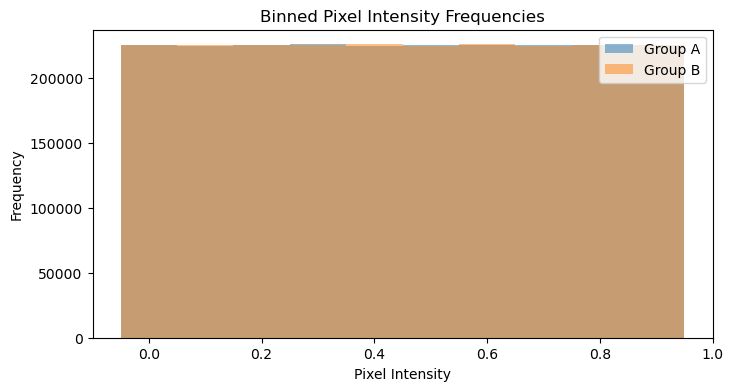

MMD (squared) = 0.000000
Hotelling's T^2: Statistic = 0.4502, p-value = 1.0000


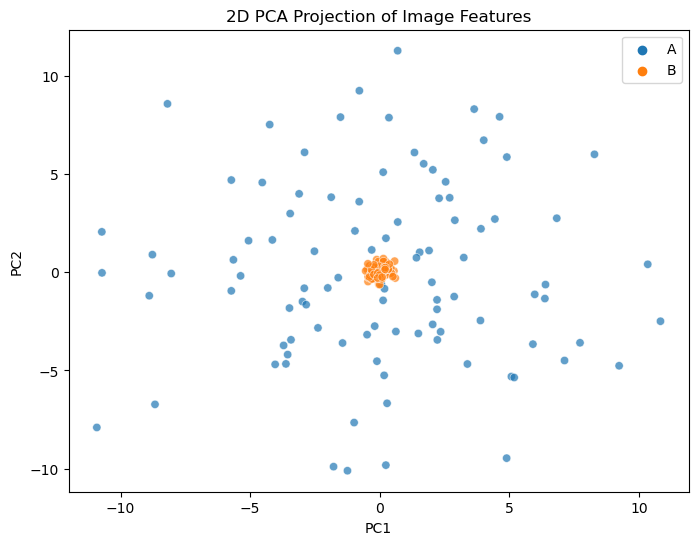

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import ks_2samp, chisquare
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# ------------------------------------------------------------------------------
# Helper Functions
# ------------------------------------------------------------------------------

def gaussian_kernel(x, y, sigma=1.0):
    """Compute the Gaussian kernel between two arrays."""
    # x and y are 2D arrays where each row is a sample.
    # We compute the squared Euclidean distance between each pair.
    diff = x[:, None] - y[None, :]
    sq_dist = np.sum(diff ** 2, axis=-1)
    return np.exp(-sq_dist / (2 * sigma**2))

def compute_mmd(x, y, sigma=1.0):
    """Compute the unbiased estimate of the squared MMD with a Gaussian kernel."""
    x = np.atleast_2d(x)
    y = np.atleast_2d(y)
    
    Kxx = gaussian_kernel(x, x, sigma)
    Kyy = gaussian_kernel(y, y, sigma)
    Kxy = gaussian_kernel(x, y, sigma)
    
    n = x.shape[0]
    m = y.shape[0]
    
    # Remove diagonal terms for Kxx and Kyy (unbiased estimate)
    sum_Kxx = np.sum(Kxx) - np.sum(np.diag(Kxx))
    sum_Kyy = np.sum(Kyy) - np.sum(np.diag(Kyy))
    
    mmd_sq = (sum_Kxx / (n * (n - 1))) + (sum_Kyy / (m * (m - 1))) - 2 * np.mean(Kxy)
    return mmd_sq

def hotelling_t2(X, Y):
    """
    Compute Hotelling's T^2 statistic and p-value for two multivariate samples.
    Here X and Y are (n_samples, n_features) arrays.
    Note: For the p-value, we use an approximate F-distribution conversion.
    """
    n, p = X.shape
    m = Y.shape[0]
    mean_diff = np.mean(X, axis=0) - np.mean(Y, axis=0)
    
    Sx = np.cov(X, rowvar=False)
    Sy = np.cov(Y, rowvar=False)
    # Pooled covariance
    Sp = ((n - 1) * Sx + (m - 1) * Sy) / (n + m - 2)
    
    try:
        Sp_inv = np.linalg.inv(Sp)
    except np.linalg.LinAlgError:
        print("Covariance matrix is singular.")
        return np.nan, np.nan

    T2 = (n * m) / (n + m) * np.dot(mean_diff.T, np.dot(Sp_inv, mean_diff))
    
    # Convert T^2 to an F-statistic
    F = ( (n + m - p - 1) * T2 ) / (p * (n + m - 2) )
    from scipy.stats import f
    p_value = 1 - f.cdf(F, p, n + m - p - 1)
    return T2, p_value

# ------------------------------------------------------------------------------
# Load or Create Your Data
# ------------------------------------------------------------------------------
# It is assumed that you have already prepared your dataset so that:
#  - 'images' is a NumPy array with shape (num_images, 150, 150, 1)
#  - 'labels' is a NumPy array with shape (num_images, 6, 6, 6)
#
# If they’re not already loaded, replace the next two lines with your loading code.
# For demonstration, we create dummy data (replace this with your own data).
np.random.seed(42)
num_images = 200
images_1 = np.random.rand(num_images, 150, 150, 1)
labels_1 = np.random.rand(num_images, 6, 6, 6)

# For testing distribution differences, we split the data randomly into two groups.
group_A_idx, group_B_idx = train_test_split(np.arange(num_images), test_size=0.5, random_state=42)
images_A = images_1[group_A_idx]
images_B = images_1[group_B_idx]

# For labels, you might perform similar splits:
labels_A = labels[group_A_idx]
labels_B = labels[group_B_idx]

# ------------------------------------------------------------------------------
# 1. UNIVARIATE TESTS
# ------------------------------------------------------------------------------

# --- 1A. Kolmogorov–Smirnov (KS) Test on Image Pixel Intensities ---
# Flatten images from both groups
pixels_A = images_A.flatten()
pixels_B = images_B.flatten()

ks_stat, ks_p = ks_2samp(pixels_A, pixels_B)
print(f"KS Test: Statistic = {ks_stat:.4f}, p-value = {ks_p:.4f}")

# --- 1B. Chi-Squared Test on Binned Pixel Intensities ---
# Bin pixel values into 10 bins for each group
bins = np.linspace(0, 1, 11)
hist_A, _ = np.histogram(pixels_A, bins=bins)
hist_B, _ = np.histogram(pixels_B, bins=bins)

# Chi-square test: comparing histograms (observed frequencies)
chi_stat, chi_p = chisquare(f_obs=hist_A, f_exp=hist_B)
print(f"Chi-Squared Test: Statistic = {chi_stat:.4f}, p-value = {chi_p:.4f}")

# Optionally, plot the binned distributions:
plt.figure(figsize=(8,4))
plt.bar(bins[:-1], hist_A, width=(bins[1]-bins[0]), alpha=0.5, label='Group A')
plt.bar(bins[:-1], hist_B, width=(bins[1]-bins[0]), alpha=0.5, label='Group B')
plt.legend()
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.title("Binned Pixel Intensity Frequencies")
plt.show()

# ------------------------------------------------------------------------------
# 2. MULTIVARIATE TESTS
# ------------------------------------------------------------------------------
# For multivariate tests, we use the flattened images as feature vectors.
# Each image is flattened to a vector of length 150*150 = 22500.
images_A_flat = images_A.reshape(images_A.shape[0], -1)
images_B_flat = images_B.reshape(images_B.shape[0], -1)

# --- 2A. Maximum Mean Discrepancy (MMD) Test ---
sigma = 0.1  # kernel bandwidth; adjust as needed
mmd_value = compute_mmd(images_A_flat, images_B_flat, sigma=sigma)
print(f"MMD (squared) = {mmd_value:.6f}")

# --- 2B. Hotelling’s T^2 Test ---
# Because images are high-dimensional, you might first reduce dimensionality.
pca = PCA(n_components=50, random_state=42)
features_A = pca.fit_transform(images_A_flat)
features_B = pca.transform(images_B_flat)

T2_stat, T2_p = hotelling_t2(features_A, features_B)
print(f"Hotelling's T^2: Statistic = {T2_stat:.4f}, p-value = {T2_p:.4f}")

# ------------------------------------------------------------------------------
# Additional: Visualize distributions from dimensionality reduction
# (This is optional and helps assess overall shifts in multivariate space)
combined_features = np.vstack([features_A, features_B])
labels_group = np.array(['A'] * features_A.shape[0] + ['B'] * features_B.shape[0])

pca_2d = PCA(n_components=2, random_state=42)
features_2d = pca_2d.fit_transform(combined_features)
plt.figure(figsize=(8,6))
sns.scatterplot(x=features_2d[:,0], y=features_2d[:,1], hue=labels_group, alpha=0.7)
plt.title("2D PCA Projection of Image Features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


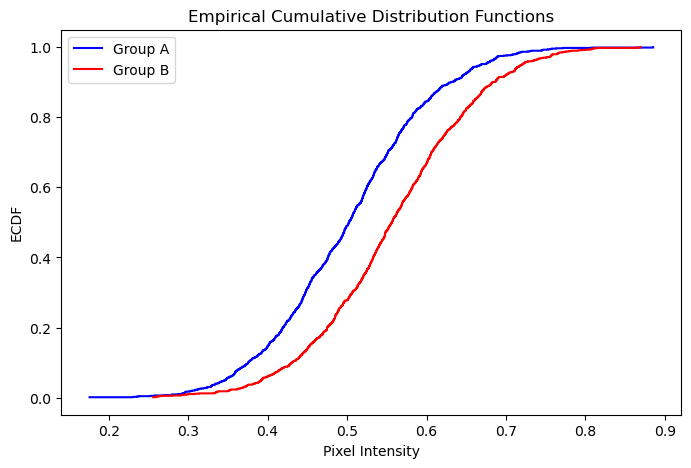

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Assume pixels_A and pixels_B are 1D arrays for the two datasets
# For demonstration, let's create dummy data:
np.random.seed(42)
pixels_A = np.random.normal(loc=0.5, scale=0.1, size=1000)
pixels_B = np.random.normal(loc=0.55, scale=0.1, size=1000)

# Function to compute ECDF
def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x)+1) / len(x)
    return x, y

x_A, y_A = ecdf(pixels_A)
x_B, y_B = ecdf(pixels_B)

plt.figure(figsize=(8, 5))
plt.step(x_A, y_A, where="post", label="Group A", color="blue")
plt.step(x_B, y_B, where="post", label="Group B", color="red")
plt.xlabel("Pixel Intensity")
plt.ylabel("ECDF")
plt.title("Empirical Cumulative Distribution Functions")
plt.legend()
plt.show()


Domain Classifier Accuracy: 100.00%


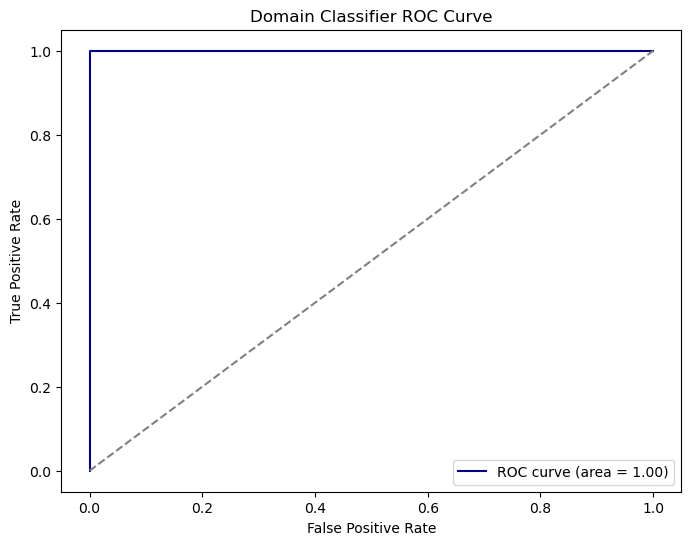

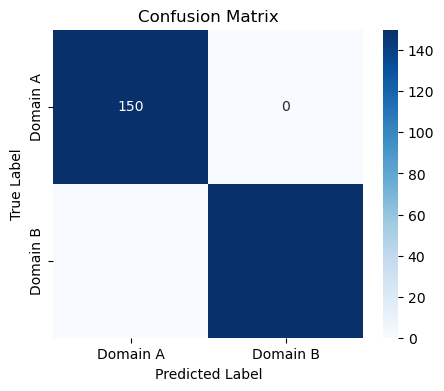

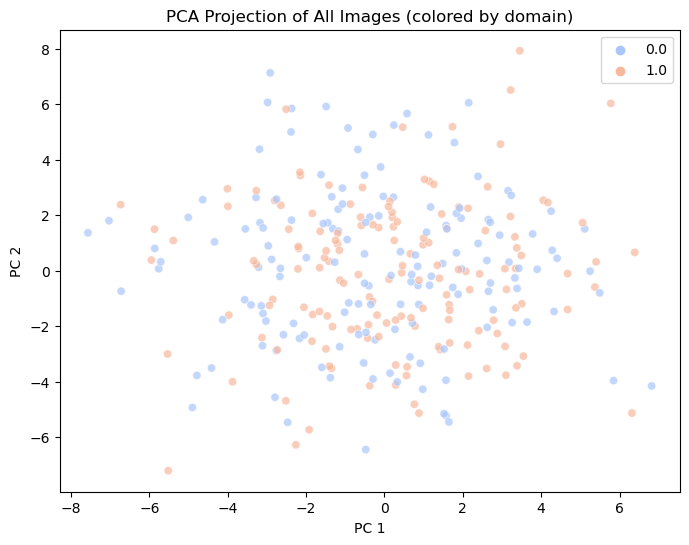

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# -----------------------------
# Assumptions:
# - 'images' is a NumPy array with shape (num_images, 150, 150, 1)
#   If not available, you can load or generate your data here.
# -----------------------------
# For demonstration, I will generate dummy data.
# Replace the code below with your actual data loading if available.
np.random.seed(42)
num_images = 300
images_1 = np.random.rand(num_images, 150, 150, 1)  # normalized grayscale images

# Flatten each image to create feature vectors.
X = images_1.reshape(num_images, -1)  # shape: (num_images, 22500)

# Split the dataset randomly into two groups.
# These two groups will play the role of "domain" A (label 0) and "domain" B (label 1).
indices = np.arange(num_images)
group_A_idx, group_B_idx = train_test_split(indices, test_size=0.5, random_state=42)
y = np.zeros(num_images)
y[group_B_idx] = 1  # Domain labels: 0 for A, 1 for B

# Now, train a domain classifier using logistic regression.
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X, y)
y_pred = clf.predict(X)
accuracy = accuracy_score(y, y_pred)
print(f"Domain Classifier Accuracy: {accuracy*100:.2f}%")

# If accuracy is near 50%, the domains are similar; high accuracy implies a shift.

# Plot a ROC curve for additional insight.
y_proba = clf.predict_proba(X)[:, 1]
fpr, tpr, thresholds = roc_curve(y, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})', color='navy')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Domain Classifier ROC Curve')
plt.legend(loc="lower right")
plt.show()

# Confusion Matrix (for further analysis)
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Domain A', 'Domain B'], yticklabels=['Domain A', 'Domain B'])
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

# Optionally, visualize the features via PCA.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='coolwarm', alpha=0.7)
plt.title("PCA Projection of All Images (colored by domain)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()


# Test-train data splitting

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

# X_train and y_train will be used for training the model
# X_test and y_test will be used for evaluating the model

In [4]:
len(X_train)

13305

In [5]:
X_train.shape

(13305, 150, 150, 1)

In [6]:
y_train.shape

(13305, 6, 6, 6)

In [7]:
len(X_test)

3327

In [8]:
len(y_train)

13305

In [9]:
len(y_test)

3327

# CNN 

# Model_1

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_even_deeper_adjusted_unet(input_shape=(150, 150, 1), num_phases=6, grid_cells=6):
    inputs = tf.keras.Input(shape=input_shape)
    
    # Encoder
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.BatchNormalization()(c1)
    c1 = layers.Activation('relu')(c1)
    c1 = layers.MaxPooling2D((2, 2))(c1)
    c1 = layers.Dropout(0.1)(c1)
    
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c1)
    c2 = layers.BatchNormalization()(c2)
    c2 = layers.Activation('relu')(c2)
    c2 = layers.MaxPooling2D((2, 2))(c2)
    c2 = layers.Dropout(0.1)(c2)
    
    # Additional encoder layers
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c2)
    c3 = layers.BatchNormalization()(c3)
    c3 = layers.Activation('relu')(c3)
    c3 = layers.MaxPooling2D((2, 2))(c3)
    c3 = layers.Dropout(0.2)(c3)
    
    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c3)
    c4 = layers.BatchNormalization()(c4)
    c4 = layers.Activation('relu')(c4)
    c4 = layers.MaxPooling2D((2, 2))(c4)
    c4 = layers.Dropout(0.2)(c4)

    # Bottleneck
    bn = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(c4)
    bn = layers.BatchNormalization()(bn)
    bn = layers.Activation('relu')(bn)
    bn = layers.Dropout(0.3)(bn)
    
    # Adjusted Decoder to directly predict grid cell structure
    pooled = layers.GlobalAveragePooling2D()(bn)
    dense = layers.Dense(grid_cells * grid_cells * num_phases, activation='linear')(pooled)
    outputs = layers.Reshape((grid_cells, grid_cells, num_phases))(dense)
    
    # Construct model
    model_1 = models.Model(inputs=[inputs], outputs=[outputs])
    
    return model_1

model_1 = build_even_deeper_adjusted_unet(input_shape=(150, 150, 1), num_phases=6, grid_cells=6)
model_1.compile(optimizer='adam', loss='mean_squared_error')
model_1.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 150, 150, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 75, 75, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 37, 37, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 18, 18, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 9, 9, 1024)     │     4,719,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 9, 9, 1024)     │         4,09

 Total params: 6,498,776 (24.79 MB)

 Trainable params: 6,494,808 (24.78 MB)

 Non-trainable params: 3,968 (15.50 KB)

In [11]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Flatten the true labels to 2D
y_train_flat = y_train.reshape(-1, y_train.shape[-1])

# Compute the mean across each phase for all grid cells
mean_label_value = np.mean(y_train_flat, axis=0)

# Create baseline predictions by replicating the mean for each sample
baseline_predictions = np.tile(mean_label_value, (y_train_flat.shape[0], 1))

# Compute the MSE
baseline_mse = mean_squared_error(y_train_flat, baseline_predictions)

print(f"Baseline MSE: {baseline_mse}")


Baseline MSE: 0.10455992230482353


In [12]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

# Define the early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # monitor the validation loss
    patience=5,  # stop after 5 epochs of no improvement
    min_delta=0.001,  # minimum change to qualify as an improvement
    restore_best_weights=True  # restore model weights from the epoch with the best value of the monitored quantity
)

# Define the reduce learning rate callback
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',  # monitor the validation loss
    factor=0.2,  # multiply the learning rate by 0.2 (reduce by 80%)
    patience=2,  # after 2 epochs with no improvement
    min_delta=0.001,  # minimum change to qualify as an improvement
    min_lr=1e-6  # minimum learning rate
)

# Train the model with the new callbacks
history = model_1.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,  # Set a higher number, early stopping will take care of stopping the training
    batch_size=32,
    callbacks=[early_stopping, reduce_lr]  # Add callbacks here
)

# Continue with testing and evaluation as before...
test_loss = model_1.evaluate(X_test, y_test)

# Plotting...
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
# Save the plot to a file (for example, "model_loss.png" in a specified directory)
save_path = "C:/Users/Mahdieh/NK/ML/0000_New_Samples_Trained/Model1/model_loss_S1-S25_2nd_WithoutInitialLR.png"  # change this to your desired path
plt.savefig(save_path, dpi=600)

plt.show()

# Displaying the test loss
print(f"Test Loss: {test_loss}")


Epoch 1/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 465s 2s/step - loss: 0.1011 - val_loss: 0.1346 - learning_rate: 0.0010
Epoch 2/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 469s 2s/step - loss: 0.0439 - val_loss: 0.1359 - learning_rate: 0.0010
Epoch 3/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 472s 2s/step - loss: 0.0379 - val_loss: 0.1107 - learning_rate: 0.0010
Epoch 4/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 473s 2s/step - loss: 0.0353 - val_loss: 0.0413 - learning_rate: 0.0010
Epoch 5/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 471s 2s/step - loss: 0.0317 - val_loss: 0.0679 - learning_rate: 0.0010
Epoch 6/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 473s 2s/step - loss: 0.0293 - val_loss: 0.0769 - learning_rate: 0.0010
Epoch 7/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 475s 2s/step - loss: 0.0269 - val_loss: 0.0283 - learning_rate: 2.0000e-04
Epoch 8/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 477s 2s/step - loss: 0.0249 - val_loss: 0.0242 - learning_rate: 2.0000e-04
Epoch 9/100
195/195 ━━━━━━━━━━━━━━━━━━━━ 479s 2s/step - loss: 0.0246 - val_loss: 0.0250 - learni

NameError: name 'plt' is not defined

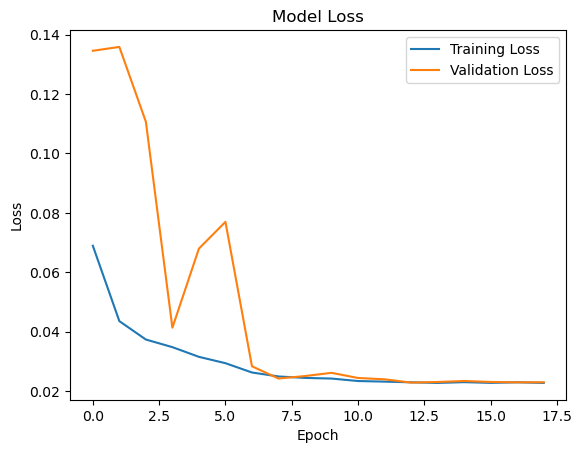

Test Loss: 0.022793380543589592


In [14]:
# Continue with testing and evaluation as before...
test_loss = model_1.evaluate(X_test, y_test)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
# Plotting...
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
# Save the plot to a file (for example, "model_loss.png" in a specified directory)
save_path = "C:/Users/Mahdieh/NK/ML/0000_New_Samples_Trained/Model1/model_loss_S1-S25_2nd_WithoutInitialLR.png"  # change this to your desired path
plt.savefig(save_path, dpi=600)

plt.show()

# Displaying the test loss
print(f"Test Loss: {test_loss}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


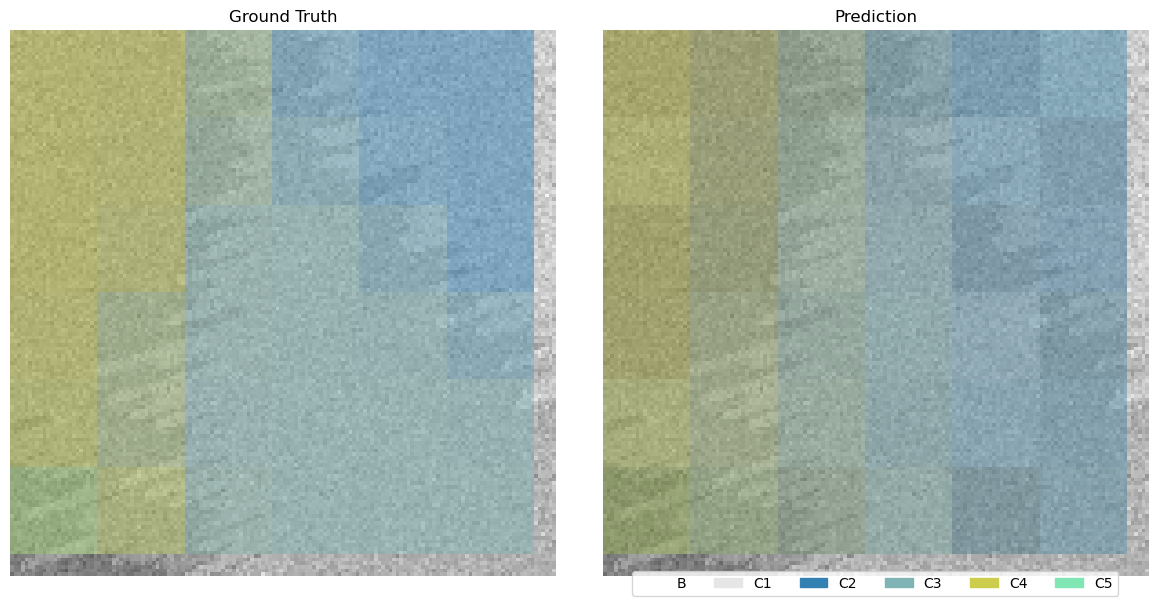

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

def get_blended_overlay(image, labels, overall_opacity=0.5):
    """
    Generate a blended overlay image from an input image and label grid.
    
    Args:
        image: A NumPy array of shape (150,150,1) with pixel values in [0,1].
        labels: A NumPy array of shape (6,6,6) representing area fractions for 6 phases.
        overall_opacity: The overall opacity applied to the computed overlay (0 to 1).
    
    Returns:
        blended_image: A PIL Image with the overlay blended onto the original image.
    """
    # Define colors for each phase (RGB in [0,1])
    phase_colors = {
        'B': np.array([1.0, 1.0, 1.0]),
        'C1': np.array([0.9, 0.9, 0.9]),
        'C2': np.array([0.2, 0.5, 0.7]),
        'C3': np.array([0.5, 0.7, 0.7]),
        'C4': np.array([0.8, 0.8, 0.3]),
        'C5': np.array([0.5, 0.9, 0.7])
    }
    phase_keys = ['B', 'C1', 'C2', 'C3', 'C4', 'C5']
    
    block_size = 24
    img_size = (150, 150)
    n_rows, n_cols, n_phases = labels.shape  # Expected to be (6,6,6)
    
    # Create an empty overlay (RGBA)
    overlay = np.zeros((img_size[0], img_size[1], 4), dtype=np.float32)
    
    # For each grid cell, compute a composite color from the phase fractions.
    # We multiply the weighted sum by an overall opacity.
    for i in range(n_rows):
        for j in range(n_cols):
            fractions = labels[i, j]  # Shape (6,)
            # Compute composite RGB color
            composite_color = np.zeros(3, dtype=np.float32)
            for idx, phase in enumerate(phase_keys):
                composite_color += fractions[idx] * phase_colors[phase]
            # Use a fixed overall opacity for all cells.
            composite_alpha = overall_opacity  
            
            rgba = np.concatenate([composite_color, [composite_alpha]])
            y0 = i * block_size
            y1 = y0 + block_size
            x0 = j * block_size
            x1 = x0 + block_size
            overlay[y0:y1, x0:x1, :] = rgba
    
    # Ensure values are clipped to [0, 1]
    overlay = np.clip(overlay, 0, 1)
    
    # Convert the overlay to an RGBA PIL image
    overlay_image = Image.fromarray((overlay * 255).astype(np.uint8), 'RGBA')
    # Convert the original grayscale image to RGBA
    original_image_pil = Image.fromarray((image.squeeze() * 255).astype(np.uint8)).convert('RGBA')
    # Composite the overlay on top of the original image
    blended_image = Image.alpha_composite(original_image_pil, overlay_image)
    return blended_image

def plot_ground_truth_vs_prediction(image, gt_labels, pred_labels, save_path=None, dpi=600):
    """
    Plots a side-by-side comparison of the ground truth and predicted area fraction overlays.
    
    Args:
        image: The input image as a NumPy array of shape (150,150,1) with values in [0,1].
        gt_labels: Ground truth label grid, shape (6,6,6)
        pred_labels: Predicted label grid, shape (6,6,6)
        save_path: Optional file path to save the plot.
        dpi: Resolution for saving the plot.
    """
    # Generate blended images for ground truth and prediction
    gt_blended = get_blended_overlay(image, gt_labels)
    pred_blended = get_blended_overlay(image, pred_labels)
    
    # Create side-by-side subplots
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(gt_blended)
    plt.axis('off')
    plt.title("Ground Truth")
    
    plt.subplot(1, 2, 2)
    plt.imshow(pred_blended)
    plt.axis('off')
    plt.title("Prediction")
    
    # Create legend for the phases
    phase_colors = {
        'B': [1.0, 1.0, 1.0],
        'C1': [0.9, 0.9, 0.9],
        'C2': [0.2, 0.5, 0.7],
        'C3': [0.5, 0.7, 0.7],
        'C4': [0.8, 0.8, 0.3],
        'C5': [0.5, 0.9, 0.7],
    }
    patches = [mpatches.Patch(color=phase_colors[key], label=key) for key in phase_colors]
    plt.legend(handles=patches, loc='lower center', ncol=len(phase_colors), bbox_to_anchor=(0.5, -0.05))
    
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=dpi)
    plt.show()

# Get prediction for test image at index 10:
y_pred = model_1.predict(X_test[4:11])
# Reshape predictions and ground truth to (6,6,6)
pred_labels = y_pred[0].reshape((6, 6, -1))
gt_labels = y_test[4].reshape((6, 6, -1))
image_example = X_test[4]

# Plot the comparison; update the save path as needed.
plot_ground_truth_vs_prediction(
    image_example, 
    gt_labels, 
    pred_labels, 
    save_path="C:/Users/Mahdieh/NK/ML/0000_New_Samples_Trained/Model1/model_1_S1-S25_2nd_WithoutInitialLR.png", 
    dpi=600
)


In [23]:
# model_1.save('C:/Users/Mahdieh/NK/ML/0000_New_Samples_Trained/Model1/Model_1')

In [20]:
model_1.save('C:/Users/Mahdieh/NK/ML/0000_New_Samples_Trained/Model1/Model_1_S1-S25_2nd_WithoutInitialLR.h5')

In [21]:
model_1.save('C:/Users/Mahdieh/NK/ML/0000_New_Samples_Trained/Model1/Model_1_S1-S25_2nd_WithoutInitialLR.keras')

# Model_2

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

def residual_block(x, filters, kernel_size=(3, 3), padding='same', strides=1):
    """
    Residual block with two convolutional layers and a shortcut connection.
    """
    res = x
    x = layers.Conv2D(filters, kernel_size, padding=padding, strides=strides)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, kernel_size, padding=padding, strides=strides)(x)
    x = layers.BatchNormalization()(x)

    # Shortcut connection
    res = layers.Conv2D(filters, kernel_size=(1, 1), padding=padding, strides=strides)(res)
    res = layers.BatchNormalization()(res)

    x = layers.add([x, res])
    x = layers.Activation('relu')(x)
    return x

def build_even_deeper_adjusted_unet(input_shape=(150, 150, 1), num_phases=6, grid_cells=6):
    inputs = tf.keras.Input(shape=input_shape)
    
    # Encoder with Residual Blocks
    c1 = residual_block(inputs, 64)
    c1 = layers.MaxPooling2D((2, 2))(c1)
    c1 = layers.Dropout(0.1)(c1)
    
    c2 = residual_block(c1, 128)
    c2 = layers.MaxPooling2D((2, 2))(c2)
    c2 = layers.Dropout(0.1)(c2)
    
    c3 = residual_block(c2, 256)
    c3 = layers.MaxPooling2D((2, 2))(c3)
    c3 = layers.Dropout(0.2)(c3)
    
    c4 = residual_block(c3, 512)
    c4 = layers.MaxPooling2D((2, 2))(c4)
    c4 = layers.Dropout(0.2)(c4)

    # Bottleneck with a deeper residual block
    bn = residual_block(c4, 1024)
    bn = layers.Dropout(0.3)(bn)
    
    # Adjusted Decoder with attention mechanism for grid cell structure prediction
    pooled = layers.GlobalAveragePooling2D()(bn)
    attention_features = layers.Dense(512, activation='relu')(pooled)
    attention_features = layers.Dense(grid_cells * grid_cells * num_phases, activation='sigmoid')(attention_features)
    attention_features = layers.Reshape((grid_cells, grid_cells, num_phases))(attention_features)
    
    dense = layers.Dense(grid_cells * grid_cells * num_phases, activation='linear')(pooled)
    outputs = layers.Reshape((grid_cells, grid_cells, num_phases))(dense)
    
    # Multiply dense output with attention features
    outputs = layers.Multiply()([outputs, attention_features])
    
    # Construct model
    model_2 = models.Model(inputs=[inputs], outputs=[outputs])
    # Construct model
    # model_2 = models.Model(inputs=inputs, outputs=outputs)

    
    return model_2

model_2 = build_even_deeper_adjusted_unet(input_shape=(150, 150, 1), num_phases=6, grid_cells=6)
model_2.compile(optimizer='adam', loss='mean_squared_error')
model_2.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 150, 150,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 150, 150,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 150, 150,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 150, 150,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 150, 150,  │        128 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 150,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 150,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 150, 150,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 150, 150,  │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 75, 75,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 75, 75,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 75, 75,    │     73,856 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 75, 75,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 75, 75,    │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 75, 75,    │      8,320 │ dropout[0][0]   

 Total params: 20,421,232 (77.90 MB)

 Trainable params: 20,409,328 (77.86 MB)

 Non-trainable params: 11,904 (46.50 KB)

Epoch 1/100


C:\Users\shakoo_m\AppData\Local\anaconda3_Personal_Seren\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 150, 150, 1))
  warnings.warn(msg)


333/333 ━━━━━━━━━━━━━━━━━━━━ 374s 1s/step - loss: 0.0779 - val_loss: 0.2236 - learning_rate: 0.0010
Epoch 2/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 364s 1s/step - loss: 0.0341 - val_loss: 0.0653 - learning_rate: 0.0010
Epoch 3/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 365s 1s/step - loss: 0.0272 - val_loss: 0.0556 - learning_rate: 0.0010
Epoch 4/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 364s 1s/step - loss: 0.0256 - val_loss: 0.0650 - learning_rate: 0.0010
Epoch 5/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 363s 1s/step - loss: 0.0231 - val_loss: 0.0223 - learning_rate: 0.0010
Epoch 6/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 364s 1s/step - loss: 0.0212 - val_loss: 0.0257 - learning_rate: 0.0010
Epoch 7/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 364s 1s/step - loss: 0.0203 - val_loss: 0.0224 - learning_rate: 0.0010
Epoch 8/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 364s 1s/step - loss: 0.0188 - val_loss: 0.0200 - learning_rate: 2.0000e-04
Epoch 9/100
333/333 ━━━━━━━━━━━━━━━━━━━━ 365s 1s/step - loss: 0.0175 - val_loss: 0.0191 - learning_rate: 2.0000e

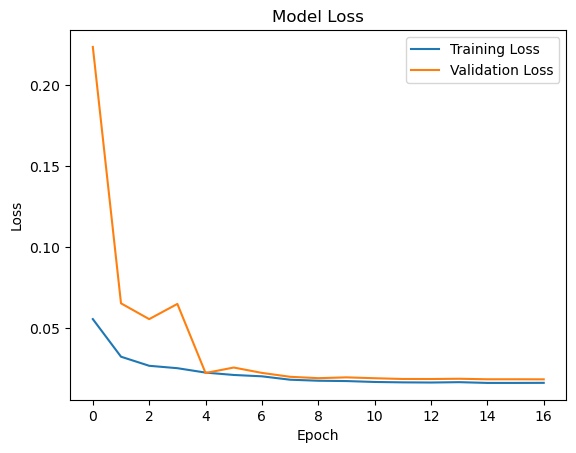

Test Loss: 0.018399594351649284


In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image


# Define the early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # monitor the validation loss
    patience=5,  # stop after 5 epochs of no improvement
    min_delta=0.001,  # minimum change to qualify as an improvement
    restore_best_weights=True  # restore model weights from the epoch with the best value of the monitored quantity
)

# Define the reduce learning rate callback
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',  # monitor the validation loss
    factor=0.2,  # multiply the learning rate by 0.2 (reduce by 80%)
    patience=2,  # after 2 epochs with no improvement
    min_delta=0.001,  # minimum change to qualify as an improvement
    min_lr=1e-6  # minimum learning rate
)

# Train the model with the new callbacks
history = model_2.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,  # Set a higher number, early stopping will take care of stopping the training
    batch_size=32,
    callbacks=[early_stopping, reduce_lr]  # Add callbacks here
)

# Continue with testing and evaluation as before...
test_loss = model_2.evaluate(X_test, y_test)

# Plotting...
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
# Save the plot to a file (for example, "model_loss.png" in a specified directory)
save_path = "G:/0000_New_Samples_Trained/Model2/model2_loss_S1-S50_WithoutInitialLR_2.png"  # change this to your desired path
plt.savefig(save_path, dpi=600)
plt.show()

# Displaying the test loss
print(f"Test Loss: {test_loss}")


In [12]:
model_2.save('G:/0000_New_Samples_Trained/Model2/model2_loss_S1-S50_WithoutInitialLR_2.h5')

In [13]:
model_2.save('G:/0000_New_Samples_Trained/Model2/model2_loss_S1-S50_WithoutInitialLR_2.keras')

C:\Users\shakoo_m\AppData\Local\anaconda3_Personal_Seren\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(8, 150, 150, 1))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step


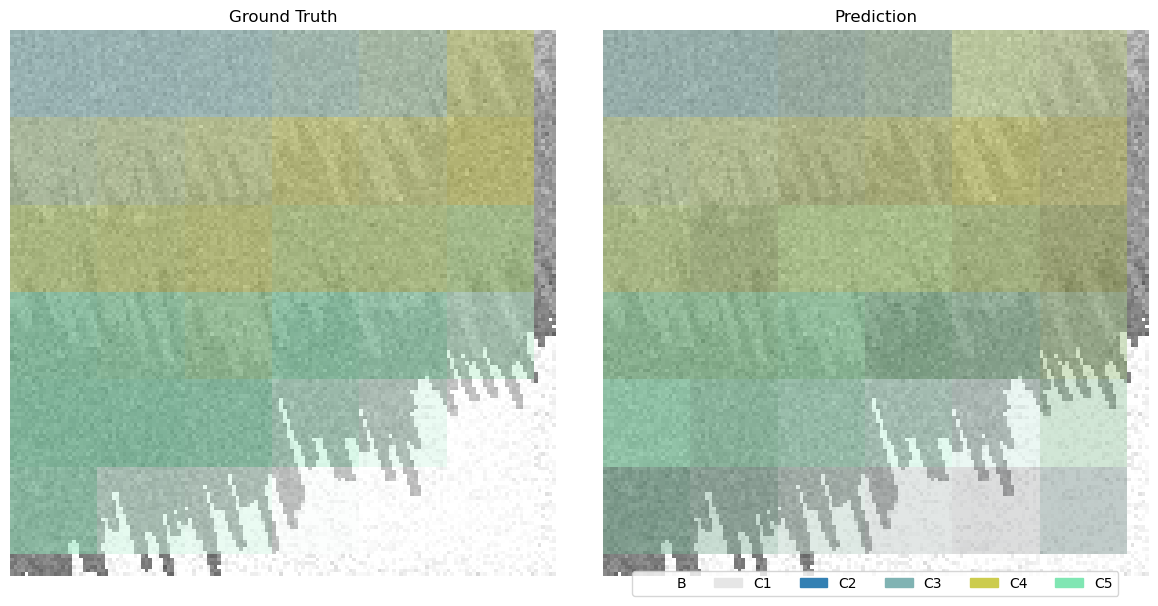

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

def get_blended_overlay(image, labels, overall_opacity=0.5):
    """
    Generate a blended overlay image from an input image and label grid.
    
    Args:
        image: A NumPy array of shape (150,150,1) with pixel values in [0,1].
        labels: A NumPy array of shape (6,6,6) representing area fractions for 6 phases.
        overall_opacity: The overall opacity applied to the computed overlay (0 to 1).
    
    Returns:
        blended_image: A PIL Image with the overlay blended onto the original image.
    """
    # Define colors for each phase (RGB in [0,1])
    phase_colors = {
        'B': np.array([1.0, 1.0, 1.0]),
        'C1': np.array([0.9, 0.9, 0.9]),
        'C2': np.array([0.2, 0.5, 0.7]),
        'C3': np.array([0.5, 0.7, 0.7]),
        'C4': np.array([0.8, 0.8, 0.3]),
        'C5': np.array([0.5, 0.9, 0.7])
    }
    phase_keys = ['B', 'C1', 'C2', 'C3', 'C4', 'C5']
    
    block_size = 24
    img_size = (150, 150)
    n_rows, n_cols, n_phases = labels.shape  # Expected to be (6,6,6)
    
    # Create an empty overlay (RGBA)
    overlay = np.zeros((img_size[0], img_size[1], 4), dtype=np.float32)
    
    # For each grid cell, compute a composite color from the phase fractions.
    # We multiply the weighted sum by an overall opacity.
    for i in range(n_rows):
        for j in range(n_cols):
            fractions = labels[i, j]  # Shape (6,)
            # Compute composite RGB color
            composite_color = np.zeros(3, dtype=np.float32)
            for idx, phase in enumerate(phase_keys):
                composite_color += fractions[idx] * phase_colors[phase]
            # Use a fixed overall opacity for all cells.
            composite_alpha = overall_opacity  
            
            rgba = np.concatenate([composite_color, [composite_alpha]])
            y0 = i * block_size
            y1 = y0 + block_size
            x0 = j * block_size
            x1 = x0 + block_size
            overlay[y0:y1, x0:x1, :] = rgba
    
    # Ensure values are clipped to [0, 1]
    overlay = np.clip(overlay, 0, 1)
    
    # Convert the overlay to an RGBA PIL image
    overlay_image = Image.fromarray((overlay * 255).astype(np.uint8), 'RGBA')
    # Convert the original grayscale image to RGBA
    original_image_pil = Image.fromarray((image.squeeze() * 255).astype(np.uint8)).convert('RGBA')
    # Composite the overlay on top of the original image
    blended_image = Image.alpha_composite(original_image_pil, overlay_image)
    return blended_image

def plot_ground_truth_vs_prediction(image, gt_labels, pred_labels, save_path=None, dpi=600):
    """
    Plots a side-by-side comparison of the ground truth and predicted area fraction overlays.
    
    Args:
        image: The input image as a NumPy array of shape (150,150,1) with values in [0,1].
        gt_labels: Ground truth label grid, shape (6,6,6)
        pred_labels: Predicted label grid, shape (6,6,6)
        save_path: Optional file path to save the plot.
        dpi: Resolution for saving the plot.
    """
    # Generate blended images for ground truth and prediction
    gt_blended = get_blended_overlay(image, gt_labels)
    pred_blended = get_blended_overlay(image, pred_labels)
    
    # Create side-by-side subplots
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(gt_blended)
    plt.axis('off')
    plt.title("Ground Truth")
    
    plt.subplot(1, 2, 2)
    plt.imshow(pred_blended)
    plt.axis('off')
    plt.title("Prediction")
    
    # Create legend for the phases
    phase_colors = {
        'B': [1.0, 1.0, 1.0],
        'C1': [0.9, 0.9, 0.9],
        'C2': [0.2, 0.5, 0.7],
        'C3': [0.5, 0.7, 0.7],
        'C4': [0.8, 0.8, 0.3],
        'C5': [0.5, 0.9, 0.7],
    }
    patches = [mpatches.Patch(color=phase_colors[key], label=key) for key in phase_colors]
    plt.legend(handles=patches, loc='lower center', ncol=len(phase_colors), bbox_to_anchor=(0.5, -0.05))
    
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=dpi)
    plt.show()

# Get prediction for test image at index 10:
y_pred = model_2.predict(X_test[3:11])
# Reshape predictions and ground truth to (6,6,6)
pred_labels = y_pred[0].reshape((6, 6, -1))
gt_labels = y_test[3].reshape((6, 6, -1))
image_example = X_test[3]

# Plot the comparison; update the save path as needed.
plot_ground_truth_vs_prediction(
    image_example, 
    gt_labels, 
    pred_labels, 
    save_path="G:/0000_New_Samples_Trained/Model2/model2_loss_S1-S50_WithoutInitialLR_2.png", 
    dpi=600
)


# Model_3

In [10]:
import os
import random
import numpy as np
import tensorflow as tf

# 1. Python built-in RNG
os.environ['PYTHONHASHSEED'] = '7'
random.seed(7)

# 2. NumPy RNG
np.random.seed(7)

# 3. TensorFlow RNG
tf.random.set_seed(7)

# 4. (Optional) Configure deterministic GPU ops
# tf.config.experimental.enable_op_determinism()

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers.schedules import ExponentialDecay

def residual_block(x, filters, kernel_size=(3, 3), padding='same', strides=1):
    """
    Enhanced residual block with squeeze-and-excitation block for attention mechanism.
    """
    res = x
    x = layers.Conv2D(filters, kernel_size, padding=padding, strides=strides)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, kernel_size, padding=padding, strides=strides)(x)
    x = layers.BatchNormalization()(x)
    
    # Squeeze and Excitation block
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(filters // 16, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)
    se = layers.Reshape((1, 1, filters))(se)
    x = layers.multiply([x, se])

    # Shortcut connection
    res = layers.Conv2D(filters, kernel_size=(1, 1), padding=padding, strides=strides)(res)
    res = layers.BatchNormalization()(res)

    x = layers.add([x, res])
    x = layers.Activation('relu')(x)
    return x

def build_even_deeper_adjusted_unet(input_shape=(150, 150, 1), num_phases=6, grid_cells=6):
    inputs = tf.keras.Input(shape=input_shape)
    
    # Encoder with Enhanced Residual Blocks
    c1 = residual_block(inputs, 64)
    c1 = layers.MaxPooling2D((2, 2))(c1)
    c1 = layers.SpatialDropout2D(0.1)(c1)
    
    c2 = residual_block(c1, 128)
    c2 = layers.MaxPooling2D((2, 2))(c2)
    c2 = layers.SpatialDropout2D(0.1)(c2)
    
    c3 = residual_block(c2, 256)
    c3 = layers.MaxPooling2D((2, 2))(c3)
    c3 = layers.SpatialDropout2D(0.2)(c3)
    
    c4 = residual_block(c3, 512)
    c4 = layers.MaxPooling2D((2, 2))(c4)
    c4 = layers.SpatialDropout2D(0.2)(c4)

    # Bottleneck with a deeper residual block
    bn = residual_block(c4, 1024)
    bn = layers.SpatialDropout2D(0.3)(bn)
    
    # Adjusted Decoder with attention mechanism for grid cell structure prediction
    pooled = layers.GlobalAveragePooling2D()(bn)
    attention_features = layers.Dense(512, activation='relu')(pooled)
    attention_features = layers.Dense(grid_cells * grid_cells * num_phases, activation='sigmoid')(attention_features)
    attention_features = layers.Reshape((grid_cells, grid_cells, num_phases))(attention_features)
    
    dense = layers.Dense(grid_cells * grid_cells * num_phases, activation='linear')(pooled)
    outputs = layers.Reshape((grid_cells, grid_cells, num_phases))(dense)
    
    # Multiply dense output with attention features
    outputs = layers.Multiply()([outputs, attention_features])
    
    # Construct model
    model_3 = models.Model(inputs=[inputs], outputs=[outputs])
    
    return model_3

# Model Compilation with Learning Rate Scheduling and AdamW optimizer
initial_learning_rate = 1e-3
lr_schedule = ExponentialDecay(
    initial_learning_rate,
    decay_steps=142,
    decay_rate=0.96,
    staircase=True)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

model_3 = build_even_deeper_adjusted_unet(input_shape=(150, 150, 1), num_phases=6, grid_cells=6)
model_3.compile(optimizer=optimizer, loss='mean_squared_error')

model_3.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 150, 150,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 150, 150,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 150, 150,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 150, 150,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 150,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │        260 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        320 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 64)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 150, 150,  │        128 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 150, 150,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 150,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 150, 150,  │          0 │ multiply[0][0],   │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 150, 150,  │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 75, 75,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 75, 75,    │          0 │ max_pooling2d[0]… │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 75, 75,    │     73,856 │ spatial_dropout2

 Total params: 20,597,932 (78.57 MB)

 Trainable params: 20,586,028 (78.53 MB)

 Non-trainable params: 11,904 (46.50 KB)

Epoch 1/100


C:\Users\shakoo_m\AppData\Local\anaconda3_Personal_Seren\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 150, 150, 1))
  warnings.warn(msg)


167/167 ━━━━━━━━━━━━━━━━━━━━ 211s 1s/step - loss: 0.0982 - val_loss: 0.1364 - learning_rate: 0.0010
Epoch 2/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - loss: 0.0490 - val_loss: 0.1489 - learning_rate: 0.0010
Epoch 3/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - loss: 0.0380 - val_loss: 0.1419 - learning_rate: 0.0010
Epoch 4/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - loss: 0.0327 - val_loss: 0.0290 - learning_rate: 0.0010
Epoch 5/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - loss: 0.0296 - val_loss: 0.0302 - learning_rate: 0.0010
Epoch 6/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - loss: 0.0276 - val_loss: 0.0241 - learning_rate: 0.0010
Epoch 7/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - loss: 0.0261 - val_loss: 0.0903 - learning_rate: 0.0010
Epoch 8/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - loss: 0.0252 - val_loss: 0.0246 - learning_rate: 0.0010
Epoch 9/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - loss: 0.0241 - val_loss: 0.0280 - learning_rate: 0.0010
Epoc

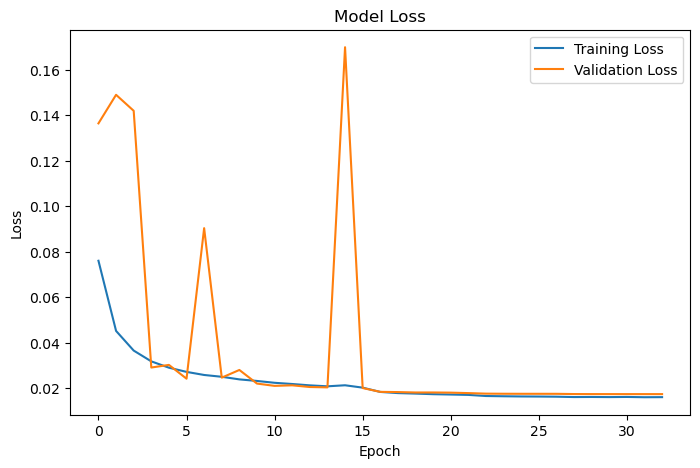

Test Loss: 0.017297234386205673


In [11]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# Create an optimizer with a fixed learning rate (float)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

# Compile your model using the fixed learning rate optimizer.
model_3.compile(optimizer=optimizer, loss='mean_squared_error')

# Define the early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',   # monitor the validation loss
    patience=2,           # stop after 5 epochs with no improvement
    min_delta=0.0001,      # minimal change to qualify as an improvement
    restore_best_weights=True  # restore weights from the best epoch
)

# Define the reduce learning rate callback
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',  # monitor the validation loss
    factor=0.1,          # reduce the learning rate by 80% when triggered
    patience=5,          # if no improvement for 2 consecutive epochs, reduce LR
    min_delta=0.001,     # minimum change to qualify as an improvement
    min_lr=1e-6          # do not lower the learning rate below 1e-6
)

# Train the model with the callbacks
history = model_3.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,          # maximum epochs; early stopping will take care of halting early
    batch_size=32,
    callbacks=[early_stopping, reduce_lr]  # attach the callbacks
)

# Evaluate the model on the test set
test_loss = model_3.evaluate(X_test, y_test)

# Plotting training and validation loss curves
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
# Save the plot to a specified path with high DPI
save_path = "G:/0000_New_Samples_Trained/Model3/model3_loss_S1-S25_WithoutInitialLR_4_RandomSeed7.png"
plt.savefig(save_path, dpi=600)
plt.show()

# Print the test loss for reference
print(f"Test Loss: {test_loss}")


Understanding the SavedModel Format
SavedModel Format: Unlike the HDF5 format, which saves the model into a single file, the SavedModel format creates a directory structure containing a full TensorFlow program, including weights, computation, and even the graph. It's designed for compatibility across a wide range of TensorFlow implementations.
Directory Structure: The message you provided points to a directory (C:/Users/Mahdieh/NK/ML/phantom/0.First_without_Brightness/Model_3) where the model and its assets have been saved. This directory contains:
The saved_model.pb file: This file describes the functional graph of the model—essentially, how the operations are connected.
The variables folder: This contains the model's weights saved in checkpoint files. These are essential for re-loading the trained model state.
The assets folder: Sometimes, additional files needed by the TensorFlow graph are stored here. For most models, this folder may be empty, but for models that require external files for operation (like vocabulary files in NLP models), this is where those would be placed.

In [12]:
model_3.save('G:/0000_New_Samples_Trained/Model3/model3_loss_S1-S25_WithoutInitialLR_4_RandomSeed7.h5')

In [13]:
model_3.save('G:/0000_New_Samples_Trained/Model3/model3_loss_S1-S25_WithoutInitialLR_4_RandomSeed7.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step


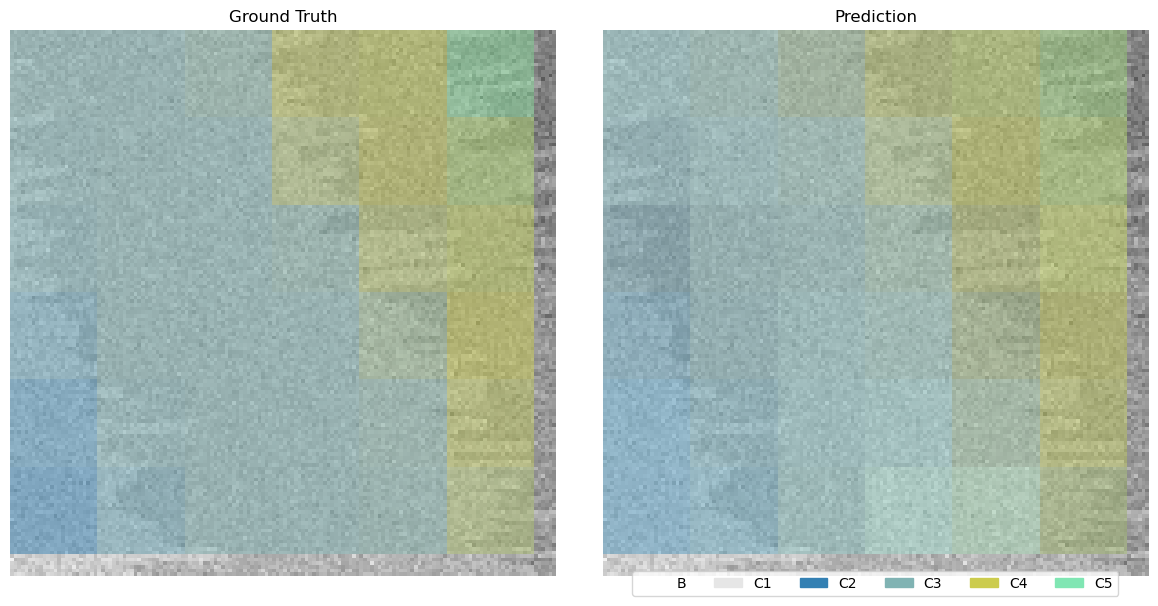

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

def get_blended_overlay(image, labels, overall_opacity=0.5):
    """
    Generate a blended overlay image from an input image and label grid.
    
    Args:
        image: A NumPy array of shape (150,150,1) with pixel values in [0,1].
        labels: A NumPy array of shape (6,6,6) representing area fractions for 6 phases.
        overall_opacity: The overall opacity applied to the computed overlay (0 to 1).
    
    Returns:
        blended_image: A PIL Image with the overlay blended onto the original image.
    """
    # Define colors for each phase (RGB in [0,1])
    phase_colors = {
        'B': np.array([1.0, 1.0, 1.0]),
        'C1': np.array([0.9, 0.9, 0.9]),
        'C2': np.array([0.2, 0.5, 0.7]),
        'C3': np.array([0.5, 0.7, 0.7]),
        'C4': np.array([0.8, 0.8, 0.3]),
        'C5': np.array([0.5, 0.9, 0.7])
    }
    phase_keys = ['B', 'C1', 'C2', 'C3', 'C4', 'C5']
    
    block_size = 24
    img_size = (150, 150)
    n_rows, n_cols, n_phases = labels.shape  # Expected to be (6,6,6)
    
    # Create an empty overlay (RGBA)
    overlay = np.zeros((img_size[0], img_size[1], 4), dtype=np.float32)
    
    # For each grid cell, compute a composite color from the phase fractions.
    # We multiply the weighted sum by an overall opacity.
    for i in range(n_rows):
        for j in range(n_cols):
            fractions = labels[i, j]  # Shape (6,)
            # Compute composite RGB color
            composite_color = np.zeros(3, dtype=np.float32)
            for idx, phase in enumerate(phase_keys):
                composite_color += fractions[idx] * phase_colors[phase]
            # Use a fixed overall opacity for all cells.
            composite_alpha = overall_opacity  
            
            rgba = np.concatenate([composite_color, [composite_alpha]])
            y0 = i * block_size
            y1 = y0 + block_size
            x0 = j * block_size
            x1 = x0 + block_size
            overlay[y0:y1, x0:x1, :] = rgba
    
    # Ensure values are clipped to [0, 1]
    overlay = np.clip(overlay, 0, 1)
    
    # Convert the overlay to an RGBA PIL image
    overlay_image = Image.fromarray((overlay * 255).astype(np.uint8), 'RGBA')
    # Convert the original grayscale image to RGBA
    original_image_pil = Image.fromarray((image.squeeze() * 255).astype(np.uint8)).convert('RGBA')
    # Composite the overlay on top of the original image
    blended_image = Image.alpha_composite(original_image_pil, overlay_image)
    return blended_image

def plot_ground_truth_vs_prediction(image, gt_labels, pred_labels, save_path=None, dpi=600):
    """
    Plots a side-by-side comparison of the ground truth and predicted area fraction overlays.
    
    Args:
        image: The input image as a NumPy array of shape (150,150,1) with values in [0,1].
        gt_labels: Ground truth label grid, shape (6,6,6)
        pred_labels: Predicted label grid, shape (6,6,6)
        save_path: Optional file path to save the plot.
        dpi: Resolution for saving the plot.
    """
    # Generate blended images for ground truth and prediction
    gt_blended = get_blended_overlay(image, gt_labels)
    pred_blended = get_blended_overlay(image, pred_labels)
    
    # Create side-by-side subplots
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(gt_blended)
    plt.axis('off')
    plt.title("Ground Truth")
    
    plt.subplot(1, 2, 2)
    plt.imshow(pred_blended)
    plt.axis('off')
    plt.title("Prediction")
    
    # Create legend for the phases
    phase_colors = {
        'B': [1.0, 1.0, 1.0],
        'C1': [0.9, 0.9, 0.9],
        'C2': [0.2, 0.5, 0.7],
        'C3': [0.5, 0.7, 0.7],
        'C4': [0.8, 0.8, 0.3],
        'C5': [0.5, 0.9, 0.7],
    }
    patches = [mpatches.Patch(color=phase_colors[key], label=key) for key in phase_colors]
    plt.legend(handles=patches, loc='lower center', ncol=len(phase_colors), bbox_to_anchor=(0.5, -0.05))
    
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=dpi)
    plt.show()

# Get prediction for test image at index 10:
y_pred = model_3.predict(X_test[70:100])
# Reshape predictions and ground truth to (6,6,6)
pred_labels = y_pred[0].reshape((6, 6, -1))
gt_labels = y_test[70].reshape((6, 6, -1))
image_example = X_test[70]

# Plot the comparison; update the save path as needed.
plot_ground_truth_vs_prediction(
    image_example, 
    gt_labels, 
    pred_labels, 
    save_path="G:/0000_New_Samples_Trained/Model3/model3_loss_S1-S25_WithoutInitialLR_4_RandomSeed7.png", 
    dpi=600
)


## Model evaluation

In [10]:
import tensorflow as tf

# # For .h5 files (legacy HDF5 format):
# model_3 = tf.keras.models.load_model(
#     'G:/0000_New_Samples_Trained/Model3/model3_loss_S1_WithoutInitialLR_2.h5'
# )


# Or for the newer .keras format:
model_1 = tf.keras.models.load_model(
    'G:/0000_New_Samples_Trained/Model1/Model_1_S1-S50_S1-S50_WithoutInitialLR.keras'
)

# Or for the newer .keras format:
model_2 = tf.keras.models.load_model(
    'G:/0000_New_Samples_Trained/Model2/model2_loss_S1-S50_WithoutInitialLR_2.keras'
)


# Or for the newer .keras format:
model_3 = tf.keras.models.load_model(
    'G:/0000_New_Samples_Trained/Model3/model3_loss_S1-S50_WithoutInitialLR_2.keras'
)


C:\Users\shakoo_m\AppData\Local\anaconda3_Personal_Seren\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 24 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
C:\Users\shakoo_m\AppData\Local\anaconda3_Personal_Seren\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 68 variables whereas the saved optimizer has 134 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
C:\Users\shakoo_m\AppData\Local\anaconda3_Personal_Seren\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 88 variables whereas the saved optimizer has 174 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [11]:
import numpy as np
# Now, compute the metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def mean_absolute_percentage_error(y_true, y_pred):
    non_zero_indices = y_true != 0
    y_true_non_zero = y_true[non_zero_indices]
    y_pred_non_zero = y_pred[non_zero_indices]
    return np.mean(np.abs((y_true_non_zero - y_pred_non_zero) / y_true_non_zero)) * 100


def coefficient_of_determination(y_true, y_pred):
    ss_res = np.sum(np.square(y_true - y_pred))
    ss_tot = np.sum(np.square(y_true - np.mean(y_true)))
    return 1 - (ss_res / ss_tot)

def huber_loss(y_true, y_pred, delta=1.0):
    error = y_true - y_pred
    is_small_error = np.abs(error) <= delta
    small_error_loss = 0.5 * np.square(error)
    large_error_loss = delta * (np.abs(error) - 0.5 * delta)
    return np.mean(np.where(is_small_error, small_error_loss, large_error_loss))

def quantile_loss(y_true, y_pred, q=0.5):
    error = y_true - y_pred
    return np.mean(np.maximum(q * error, (q - 1) * error))

def evaluate_model(model, X_train, y_train, X_test, y_test):
    # Train predictions
    y_train_pred = model.predict(X_train)
    # Test predictions
    y_test_pred = model.predict(X_test)
    
    # Metrics
    train_mses = []
    test_mses = []
    train_maes = []
    test_maes = []
    train_r2s = []
    test_r2s = []
    train_mapes = []
    test_mapes = []
    train_cds = []
    test_cds = []
    train_huber_losses = []
    test_huber_losses = []
    train_quantile_losses = []
    test_quantile_losses = []
    
    for i in range(y_train.shape[1]):
        train_mses.append(mean_squared_error(y_train[:, :, :, i].flatten(), y_train_pred[:, :, :, i].flatten()))
        test_mses.append(mean_squared_error(y_test[:, :, :, i].flatten(), y_test_pred[:, :, :, i].flatten()))
        train_maes.append(mean_absolute_error(y_train[:, :, :, i].flatten(), y_train_pred[:, :, :, i].flatten()))
        test_maes.append(mean_absolute_error(y_test[:, :, :, i].flatten(), y_test_pred[:, :, :, i].flatten()))
        train_r2s.append(r2_score(y_train[:, :, :, i].flatten(), y_train_pred[:, :, :, i].flatten()))
        test_r2s.append(r2_score(y_test[:, :, :, i].flatten(), y_test_pred[:, :, :, i].flatten()))
        train_mapes.append(mean_absolute_percentage_error(y_train[:, :, :, i].flatten(), y_train_pred[:, :, :, i].flatten()))
        test_mapes.append(mean_absolute_percentage_error(y_test[:, :, :, i].flatten(), y_test_pred[:, :, :, i].flatten()))
        train_cds.append(coefficient_of_determination(y_train[:, :, :, i].flatten(), y_train_pred[:, :, :, i].flatten()))
        test_cds.append(coefficient_of_determination(y_test[:, :, :, i].flatten(), y_test_pred[:, :, :, i].flatten()))
        train_huber_losses.append(huber_loss(y_train[:, :, :, i].flatten(), y_train_pred[:, :, :, i].flatten()))
        test_huber_losses.append(huber_loss(y_test[:, :, :, i].flatten(), y_test_pred[:, :, :, i].flatten()))
        train_quantile_losses.append(quantile_loss(y_train[:, :, :, i].flatten(), y_train_pred[:, :, :, i].flatten()))
        test_quantile_losses.append(quantile_loss(y_test[:, :, :, i].flatten(), y_test_pred[:, :, :, i].flatten()))
    
    return train_mses, test_mses, train_maes, test_maes, train_r2s, test_r2s, \
           train_mapes, test_mapes, train_cds, test_cds, train_huber_losses, test_huber_losses, \
           train_quantile_losses, test_quantile_losses


In [12]:
# Assuming you have three trained models named model_1, model_2, and model_3
# X_train, y_train, X_test, and y_test are your training and testing data

# Evaluate Model 1
print("Evaluation for Model 1:")
train_mses_1, test_mses_1, train_maes_1, test_maes_1, train_r2s_1, test_r2s_1, \
train_mapes_1, test_mapes_1, train_cds_1, test_cds_1, train_huber_losses_1, test_huber_losses_1, \
train_quantile_losses_1, test_quantile_losses_1 = evaluate_model(model_1, X_train, y_train, X_test, y_test)

# Evaluate Model 2
print("Evaluation for Model 2:")
train_mses_2, test_mses_2, train_maes_2, test_maes_2, train_r2s_2, test_r2s_2, \
train_mapes_2, test_mapes_2, train_cds_2, test_cds_2, train_huber_losses_2, test_huber_losses_2, \
train_quantile_losses_2, test_quantile_losses_2 = evaluate_model(model_2, X_train, y_train, X_test, y_test)

# Evaluate Model 3
print("Evaluation for Model 3:")
train_mses_3, test_mses_3, train_maes_3, test_maes_3, train_r2s_3, test_r2s_3, \
train_mapes_3, test_mapes_3, train_cds_3, test_cds_3, train_huber_losses_3, test_huber_losses_3, \
train_quantile_losses_3, test_quantile_losses_3 = evaluate_model(model_3, X_train, y_train, X_test, y_test)


Evaluation for Model 1:
416/416 ━━━━━━━━━━━━━━━━━━━━ 30s 71ms/step
104/104 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step
Evaluation for Model 2:
416/416 ━━━━━━━━━━━━━━━━━━━━ 97s 231ms/step
104/104 ━━━━━━━━━━━━━━━━━━━━ 24s 228ms/step
Evaluation for Model 3:
416/416 ━━━━━━━━━━━━━━━━━━━━ 108s 260ms/step
104/104 ━━━━━━━━━━━━━━━━━━━━ 27s 262ms/step


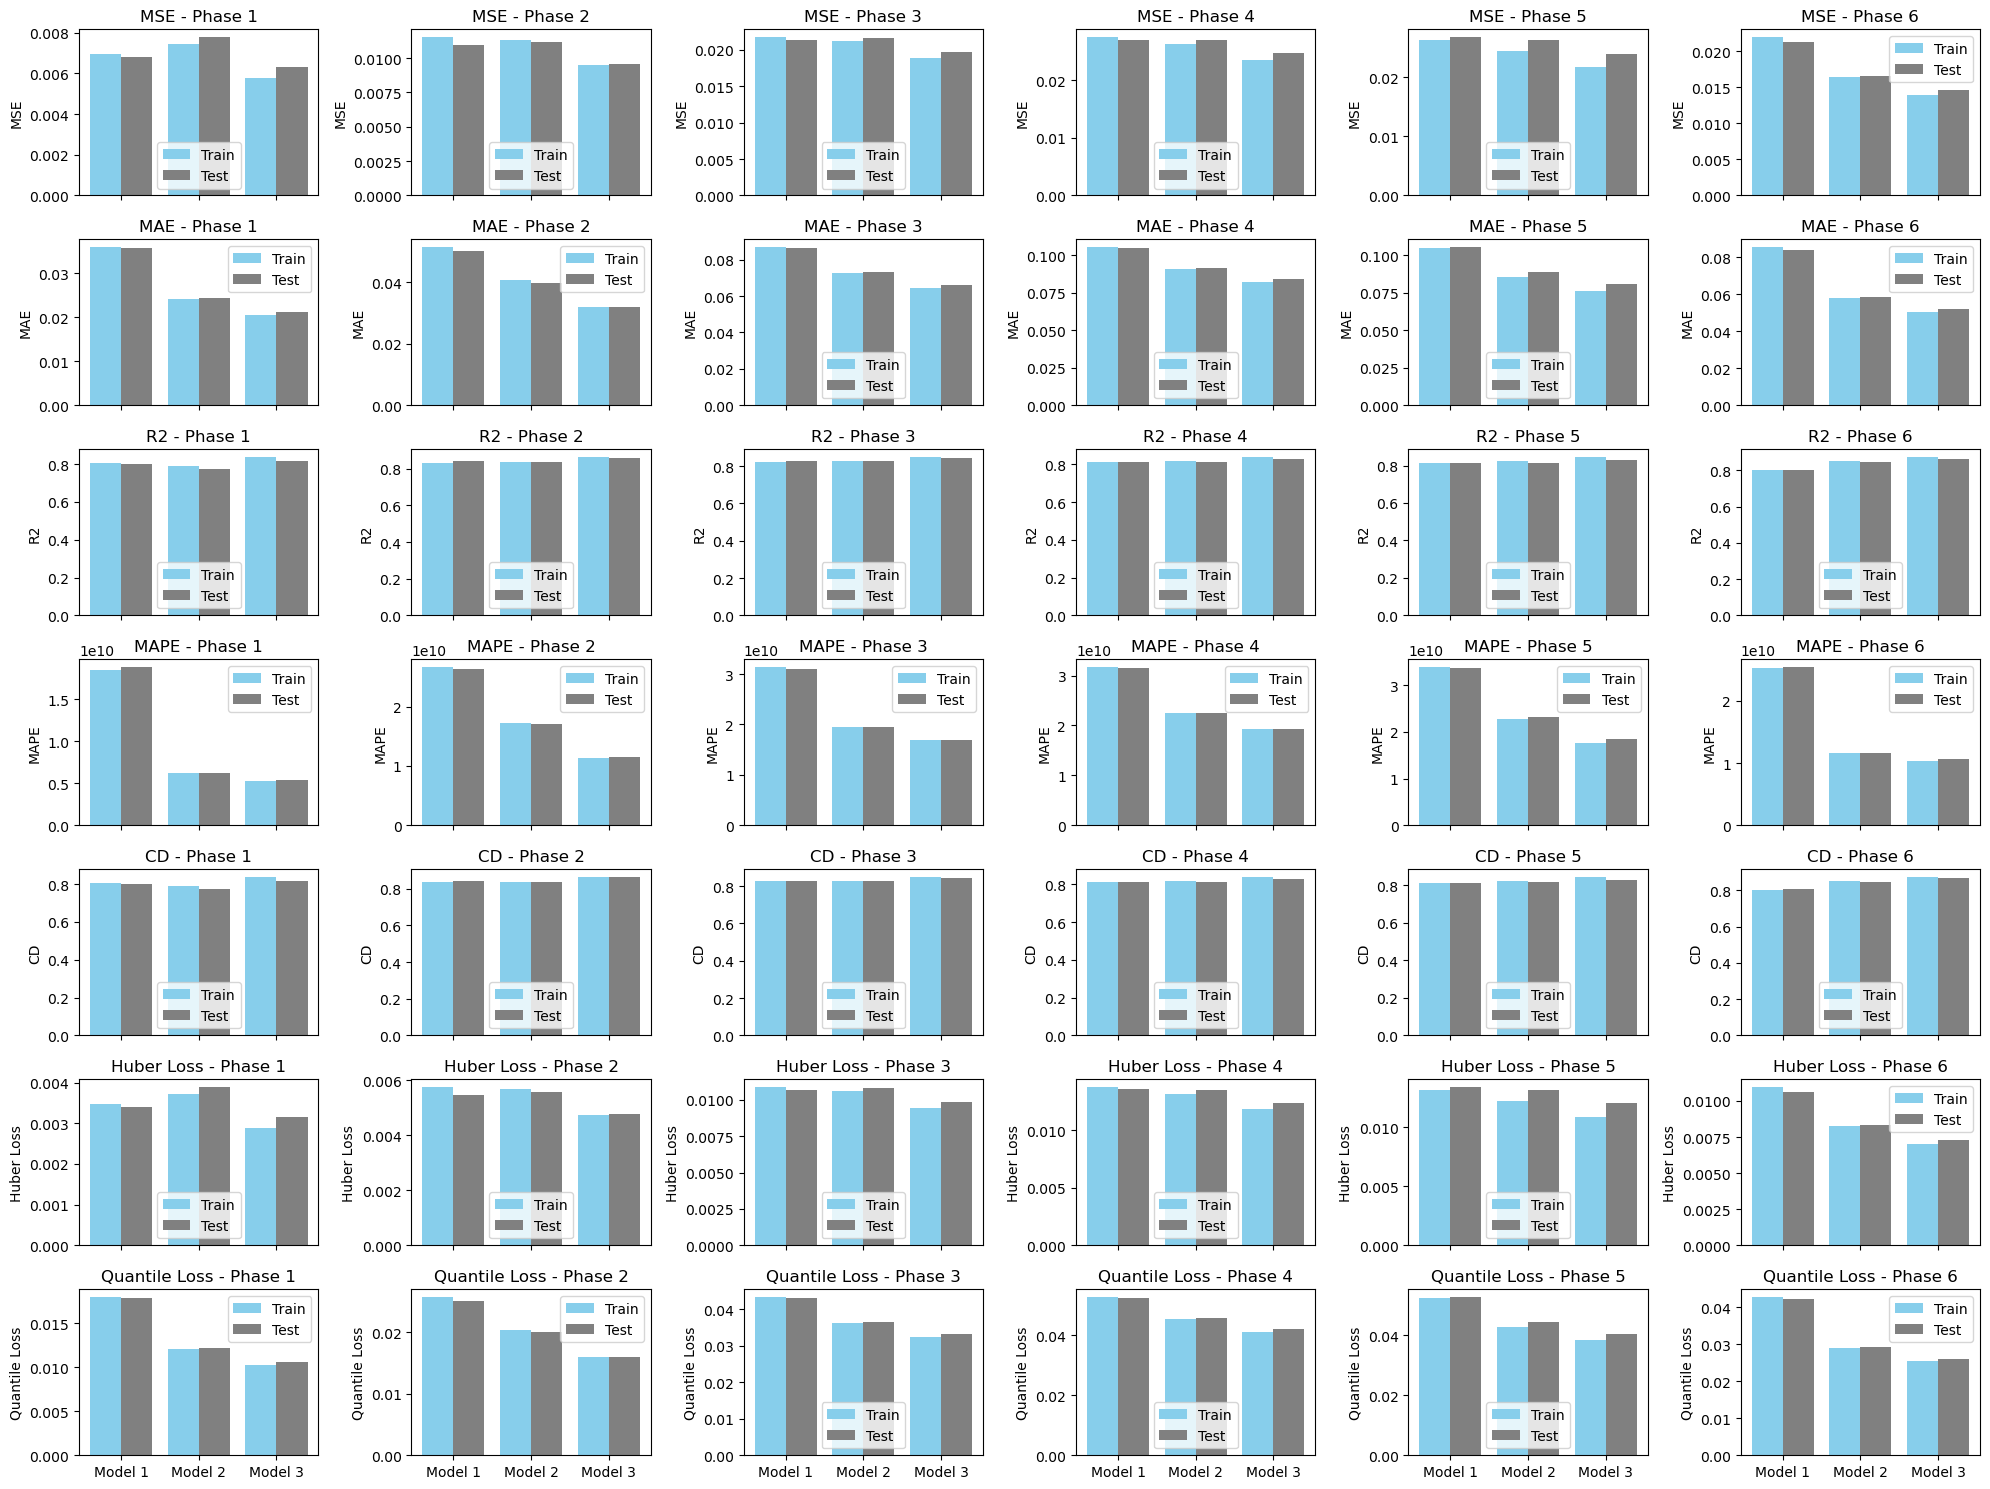

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics and phase names
metrics = ['MSE', 'MAE', 'R2', 'MAPE', 'CD', 'Huber Loss', 'Quantile Loss']
phases = ['Phase 1', 'Phase 2', 'Phase 3', 'Phase 4', 'Phase 5', 'Phase 6']

# Colors for train and test bars
colors = ['skyblue', 'gray']
models_data = [
    [train_mses_1, test_mses_1, train_maes_1, test_maes_1, train_r2s_1, test_r2s_1, 
     train_mapes_1, test_mapes_1, train_cds_1, test_cds_1, train_huber_losses_1, 
     test_huber_losses_1, train_quantile_losses_1, test_quantile_losses_1],
    [train_mses_2, test_mses_2, train_maes_2, test_maes_2, train_r2s_2, test_r2s_2, 
     train_mapes_2, test_mapes_2, train_cds_2, test_cds_2, train_huber_losses_2, 
     test_huber_losses_2, train_quantile_losses_2, test_quantile_losses_2],
    [train_mses_3, test_mses_3, train_maes_3, test_maes_3, train_r2s_3, test_r2s_3, 
     train_mapes_3, test_mapes_3, train_cds_3, test_cds_3, train_huber_losses_3, 
     test_huber_losses_3, train_quantile_losses_3, test_quantile_losses_3]
]
models_data = np.array(models_data)

# Plotting
fig, axs = plt.subplots(len(metrics), len(phases), figsize=(20, 15), sharex=True)

for i, metric in enumerate(metrics):
    for j, phase in enumerate(phases):
        # Extracting data for the current metric and phase
        train_data = models_data[:, i*2, j]
        test_data = models_data[:, i*2+1, j]
        
        # Bar positions
        x = np.arange(len(train_data))
        
        # Plotting train and test data
        axs[i, j].bar(x - 0.2, train_data, width=0.4, color=colors[0], label='Train')
        axs[i, j].bar(x + 0.2, test_data, width=0.4, color=colors[1], label='Test')
        
        # Setting labels and title
        axs[i, j].set_title(f'{metric} - {phase}')
        axs[i, j].set_ylabel(metric)
        axs[i, j].set_xticks(x)
        axs[i, j].set_xticklabels([f'Model {k+1}' for k in range(len(train_data))])
        axs[i, j].legend()

# Adjust layout
plt.tight_layout()
save_path = "G:/0000_New_Samples_Trained/000_Evaluations/models_S1-S50_3rd.png"
plt.savefig(save_path, dpi=600)
plt.show()


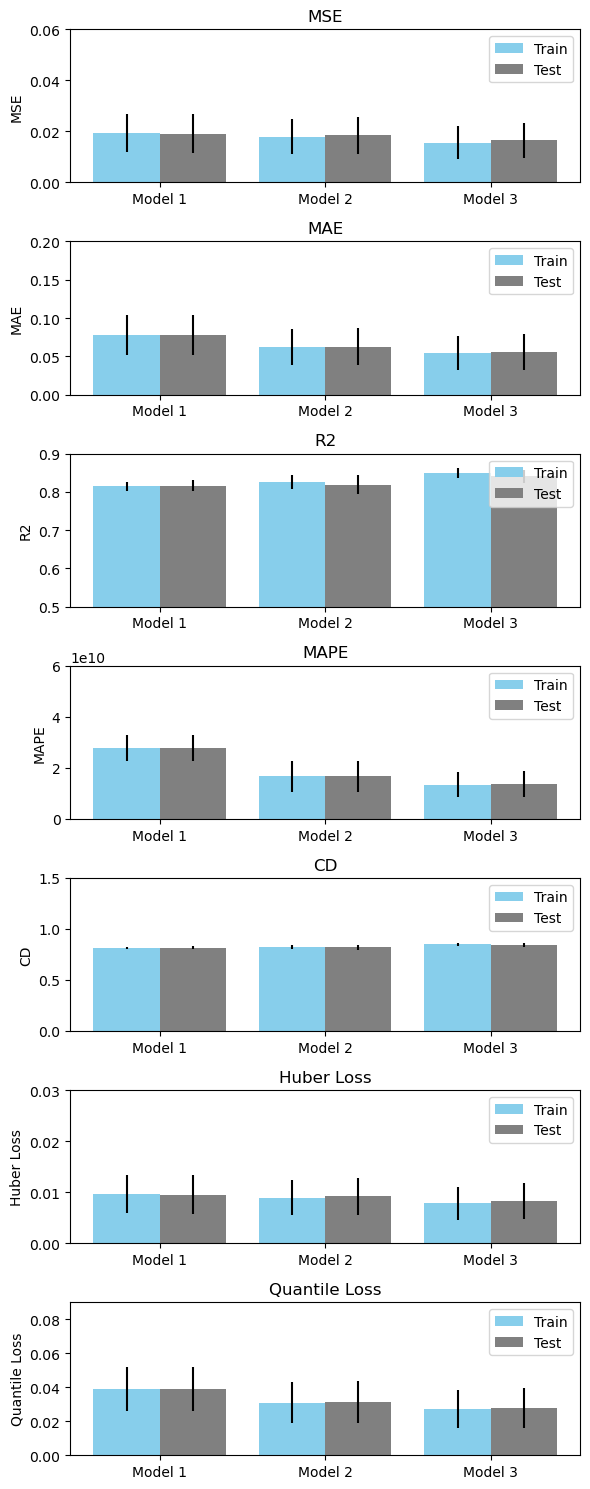

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics names
metrics = ['MSE', 'MAE', 'R2', 'MAPE', 'CD', 'Huber Loss', 'Quantile Loss']

# Colors for train and test bars
colors = ['skyblue', 'gray']

# Calculate average and standard deviation across phases for each metric
avg_train = np.mean(models_data[:, ::2, :], axis=2)
avg_test = np.mean(models_data[:, 1::2, :], axis=2)
std_train = np.std(models_data[:, ::2, :], axis=2)
std_test = np.std(models_data[:, 1::2, :], axis=2)

# Plotting
# define the y‐limits you want for each metric
y_limits = {
    'MSE':        (0.0, 0.06),
    'MAE':        (0.0, 0.2),
    'R2':         (0.5, 0.9),
    'MAPE':       (0.0, 6e10),
    'CD':         (0.0, 1.5),
    'Huber Loss': (0.0, 0.03),
    'Quantile Loss': (0.0, 0.09),
}

fig, axs = plt.subplots(len(metrics), figsize=(6, 15))

for i, metric in enumerate(metrics):
    # Bar positions
    x = np.arange(len(avg_train))
    
    # Plotting average and standard deviation
    axs[i].bar(x - 0.2, avg_train[:, i], yerr=std_train[:, i], width=0.4, color=colors[0], label='Train')
    axs[i].bar(x + 0.2, avg_test[:, i], yerr=std_test[:, i], width=0.4, color=colors[1], label='Test')
    
    # Setting labels and title
    axs[i].set_title(metric)
    axs[i].set_ylabel(metric)
    axs[i].set_xticks(x)
    axs[i].set_xticklabels([f'Model {k+1}' for k in range(len(avg_train))])
    axs[i].legend()
    
    # force the y‐axis to your chosen limits
    if metric in y_limits:
        axs[i].set_ylim(y_limits[metric])


# Adjust layout
plt.tight_layout()
save_path = "G:/0000_New_Samples_Trained/000_Evaluations/models_S1-S50_3rd_average.png"
plt.savefig(save_path, dpi=600)
plt.show()
